# **Problem Statement**

### Business Context

The prices of the stocks of companies listed under a global exchange are influenced by a variety of factors, with the company's financial performance, innovations and collaborations, and market sentiment being factors that play a significant role. News and media reports can rapidly affect investor perceptions and, consequently, stock prices in the highly competitive financial industry. With the sheer volume of news and opinions from a wide variety of sources, investors and financial analysts often struggle to stay updated and accurately interpret its impact on the market. As a result, investment firms need sophisticated tools to analyze market sentiment and integrate this information into their investment strategies.

### Problem Definition

With an ever-rising number of news articles and opinions, an investment startup aims to leverage artificial intelligence to address the challenge of interpreting stock-related news and its impact on stock prices. They have collected historical daily news for a specific company listed under NASDAQ, along with data on its daily stock price and trade volumes.

As a member of the Data Science and AI team in the startup, you have been tasked with analyzing the data, developing an AI-driven sentiment analysis system that will automatically process and analyze news articles to gauge market sentiment, and summarizing the news at a weekly level to enhance the accuracy of their stock price predictions and optimize investment strategies. This will empower their financial analysts with actionable insights, leading to more informed investment decisions and improved client outcomes.

### Data Dictionary

* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

# **Installing and Importing Necessary Libraries**

In [1]:
# installing the sentence-transformers and gensim libraries for word embeddings
!pip install -U sentence-transformers gensim transformers tqdm -q

In [2]:
# to read and manipulate the data
import pandas as pd
import numpy as np
pd.set_option('max_colwidth', None)    # setting column to the maximum column width as per the data

# to visualise data
import matplotlib.pyplot as plt
import seaborn as sns

# to use regular expressions for manipulating text data
import re

# to load the natural language toolkit
import nltk
nltk.download('stopwords')    # loading the stopwords
nltk.download('wordnet')    # loading the wordnet module that is used in stemming

# to remove common stop words
from nltk.corpus import stopwords

# to perform stemming
from nltk.stem.porter import PorterStemmer

# To encode the target variable
from sklearn.preprocessing import LabelEncoder

# To import Word2Vec
from gensim.models import Word2Vec

# To tune the model
from sklearn.model_selection import GridSearchCV

# Converting the Stanford GloVe model vector format to word2vec
from gensim.scripts.glove2word2vec import glove2word2vec
from gensim.models import KeyedVectors

# to load transformer models
from sentence_transformers import SentenceTransformer
from transformers import T5Tokenizer, T5ForConditionalGeneration, pipeline

# To split data into train and test sets
from sklearn.model_selection import train_test_split

# To build a Random Forest model
from sklearn.ensemble import RandomForestClassifier

# To compute metrics to evaluate the model
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, classification_report

# to compute distances
from scipy.spatial.distance import cdist, pdist
from sklearn.metrics import silhouette_score

# importing the PyTorch Deep Learning library
import torch

# to cluster the data
from sklearn.cluster import KMeans

# to compute metrics
from sklearn.metrics import classification_report

# to avoid displaying unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


# **Loading the dataset**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# loading data into a pandas dataframe
stock_news = pd.read_csv("/content/drive/MyDrive/NLP/stock_news.csv")

# **Data Overview**

## **Create a copy of the data**

In [5]:
# creating a copy of the data
data = stock_news.copy()

## **Checking the first 5 rows**

In [6]:
data.head()

,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,"The tech sector experienced a significant decline in the aftermarket following Apple's Q1 revenue warning. Notable suppliers, including Skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple's downward revision of its revenue expectations for the quarter, previously announced in January.",41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,"Apple lowered its fiscal Q1 revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales. The announcement caused a significant drop in Apple's stock price and negatively impacted related suppliers, leading to broader market declines for tech indices such as Nasdaq 10",41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,"Apple cut its fiscal first quarter revenue forecast from $89-$93 billion to $84 billion due to weaker demand in China and fewer iPhone upgrades. CEO Tim Cook also mentioned constrained sales of Airpods and Macbooks. Apple's shares fell 8.5% in post market trading, while Asian suppliers like Hon",41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,"This news article reports that yields on long-dated U.S. Treasury securities hit their lowest levels in nearly a year on January 2, 2019, due to concerns about the health of the global economy following weak economic data from China and Europe, as well as the partial U.S. government shutdown. Apple",41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,"Apple's revenue warning led to a decline in USD JPY pair and a gain in Japanese yen, as investors sought safety in the highly liquid currency. Apple's underperformance in Q1, with forecasted revenue of $84 billion compared to analyst expectations of $91.5 billion, triggered risk aversion mood in markets",41.740002,42.244999,41.482498,40.246914,130672400,-1


## **Checking the last 5 rows**

In [7]:
data.tail()

,Date,News,Open,High,Low,Close,Volume,Label
344,2019-04-30,"Media mogul Oprah Winfrey, known for influencing millions with her opinions on diets and books, is considering which Democratic presidential candidate to endorse in 2020. She told the Hollywood Reporter she's ""quietly figuring out where I'm going to use my voice"" and will make a clear announcement",50.764999,50.849998,49.7775,48.70879,186139600,-1
345,2019-04-30,"European shares fell on Tuesday, with banks underperforming amid a decline in China's manufacturing activity and awaiting euro zone economic growth numbers. The pan-European STOXX 600 index dropped 0.7% while major indices fell except London's FTSE 100. Danske Bank plunged",50.764999,50.849998,49.7775,48.70879,186139600,-1
346,2019-04-30,"This article reports that the S&P 500 reached another record high close on Tuesday, marking its best four-month stretch since late 2010. Apple's strong quarterly results and positive earnings forecast helped ease concerns about the bull run's sustainability, despite a revenue miss from Google parent Alphabet. The",50.764999,50.849998,49.7775,48.70879,186139600,-1
347,2019-04-30,"The Federal Reserve is anticipated to keep interest rates unchanged in their upcoming meeting, with a likelihood of a rate cut expected later this year. The Fed Chairman's press conference may provide significant market impact as investors seek insights on economic growth and inflation. Apple's earnings report exceeded expectations, leading to a post-market surge in shares, while",50.764999,50.849998,49.7775,48.70879,186139600,-1
348,2019-04-30,"In the first quarter, South Korea's Samsung Electronics reported its weakest profit in over two years due to falls in chip prices and slowing demand for display panels. The tech giant expects improved results in the second half of 2019, driven by a pickup in memory chip and smartphone sales. However, memory chip",50.764999,50.849998,49.7775,48.70879,186139600,0


## **Checking the shape of the data**

In [8]:
data.shape

(349, 8)

### Observations:

- There are **349 rows** & **8 columns** in the given dataset.

## **Checking the data types of the columns for the dataset**

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    349 non-null    object 
 1   News    349 non-null    object 
 2   Open    349 non-null    float64
 3   High    349 non-null    float64
 4   Low     349 non-null    float64
 5   Close   349 non-null    float64
 6   Volume  349 non-null    int64  
 7   Label   349 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 21.9+ KB


In [10]:
# group by data type
data.dtypes.value_counts()

,count
float64,4
object,2
int64,2


### Observations:

- The dataset contains **2 object-type columns** and **6 numerical columns** (integer and float).
- All columns have *349 observations*, indicating there are **no missing values**.
- The `Date` column is currently of *object type* and should be converted to *DateTime format*.
- The `Label` column contains *three unique values (-1, 0, 1)*, representing sentiment polarity, and should be converted to *categorical data type*.


## **Statistical summary of the dataset**

In [11]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,349.0,4.622923e+01,6.442817e+00,3.756750e+01,4.174000e+01,4.597500e+01,5.070750e+01,6.681750e+01
High,349.0,4.670046e+01,6.507321e+00,3.781750e+01,4.224500e+01,4.602500e+01,5.085000e+01,6.706250e+01
Low,349.0,4.574539e+01,6.391976e+00,3.730500e+01,4.148250e+01,4.564000e+01,4.977750e+01,6.586250e+01
Close,349.0,4.492632e+01,6.398338e+00,3.625413e+01,4.024691e+01,4.459692e+01,4.911079e+01,6.480523e+01
Volume,349.0,1.289482e+08,4.317031e+07,4.544800e+07,1.032720e+08,1.156272e+08,1.511252e+08,2.444392e+08
Label,349.0,-5.444126e-02,7.151192e-01,-1.000000e+00,-1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


### **Observations**:

- The dataset contains **349 observations** for each column.

- **Stock Prices (Open, High, Low, Close):**
  - The **mean Open price** is approximately **\$46.22**, while the **Close price** averages **\$44.92**, showing slight downward movement.
  - The **maximum price** observed is around **\$66.81** (Open), and the **minimum price** is around **\$36.25** (Close).
  - Price variability is moderate, with a standard deviation of around **6.4** across all price columns.

- **Volume:**
  - The average trading volume is approximately **128.95 million shares**, with a wide range from **45.44 million** to **244.43 million**, indicating high variability in trading activity.
  
- **Label (Sentiment Polarity):**
  - The mean value is **-0.054**, slightly leaning toward the **negative side**.
  - The range is from **-1 to 1**, confirming the presence of **three sentiment classes**: negative, neutral, and positive.



## **Checking for missing values**

In [12]:
data.isnull().sum()

,0
Date,0
News,0
Open,0
High,0
Low,0
Close,0
Volume,0
Label,0


### Observations:

- As we can see, all the columns has **0 missing values**. It means, there are **no missing values** in the data.

## Checking for duplicate values

In [13]:
data.duplicated().sum()

0

### Observations:

- There are **no duplicate values** in the data.

# **Exploratory Data Analysis (EDA)**

## Convert Date object into Date format

In [14]:
data['Date'] = pd.to_datetime(data['Date'])

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    349 non-null    datetime64[ns]
 1   News    349 non-null    object        
 2   Open    349 non-null    float64       
 3   High    349 non-null    float64       
 4   Low     349 non-null    float64       
 5   Close   349 non-null    float64       
 6   Volume  349 non-null    int64         
 7   Label   349 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(2), object(1)
memory usage: 21.9+ KB


## **Model Support Functions**

In [16]:
# function to create both Histogram & Box-Plot

def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined
    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        # data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
        data=data, x=feature, ax=ax_box2, showmeans=True
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        # data[feature].mean(), color="green", linestyle="--"
        data[feature].mean(), linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        # data[feature].median(), color="black", linestyle="-"
        data[feature].median(), linestyle="-"
    )  # Add median to the histogram

In [17]:
# function to create Barplot

def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top
    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="deep",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = int(p.get_height())  # count of each level of the category without decimals

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot


In [18]:
def plot_sentiment_vs_price(df, sentiment_col='Label', price_col='Close'):
    """
    Plots how stock price varies with sentiment using a box plot.

    Parameters:
    - df: DataFrame
    - sentiment_col: Column with sentiment polarity (default = 'Label')
    - price_col: Stock price column to analyze (default = 'Close')
    """
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=sentiment_col, y=price_col, data=df, palette={1: 'green', 0: 'gray', -1: 'red'})
    plt.title(f"{price_col} vs Sentiment Polarity")
    plt.xlabel("Sentiment Polarity (-1 = Negative, 0 = Neutral, 1 = Positive)")
    if price_col == 'Volume':
        plt.ylabel(f"{price_col} (Number of Shares)")
    else:
        plt.ylabel(f"{price_col} Price ($)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [19]:
def plot_date_vs_price(df, date_col='Date', price_col='Close'):
    """
    Plots stock price over time.

    Parameters:
    - df: DataFrame
    - date_col: Column with date values
    - price_col: Price column to plot (e.g., 'Close')
    """
    df_copy = df.copy()
    df_copy[date_col] = pd.to_datetime(df_copy[date_col])
    df_copy.sort_values(by=date_col, inplace=True)

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_copy, x=date_col, y=price_col, color='steelblue')
    plt.title(f"{price_col} Price Over Time")
    plt.xlabel("Date")
    if price_col == 'Volume':
        plt.ylabel(f"{price_col} (Number of Shares)")
    else:
        plt.ylabel(f"{price_col} Price ($)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [20]:
def plot_sentiment_vs_price(data, sentiment_col='Label', price_col='Close'):
    """
    Plots a boxplot of a price column grouped by sentiment labels.

    Parameters:
    - data: DataFrame containing the data
    - sentiment_col: Column name for sentiment labels (default 'Label')
    - price_col: Column name for the numeric price to plot (default 'Close')
    """

    # Convert sentiment column to string to avoid palette mapping errors
    data['Sentiment_str'] = data[sentiment_col].astype(str)

    # Define palette
    palette = {
        '-1': 'red',
        '0': 'gray',
        '1': 'green'
    }

    # Plot
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='Sentiment_str', y=price_col, data=data, palette=palette)
    plt.title(f"{price_col} Distribution by Sentiment")
    plt.xlabel("Sentiment Polarity (-1: Negative, 0: Neutral, 1: Positive)")
    plt.ylabel(f"{price_col} Price")
    plt.grid(False)
    plt.tight_layout()
    plt.show()


## **Univariate Analysis**

* Distribution of individual variables
* Compute and check the distribution of the length of news content

### Distribution of **`Open`** *(Numerical Column)*

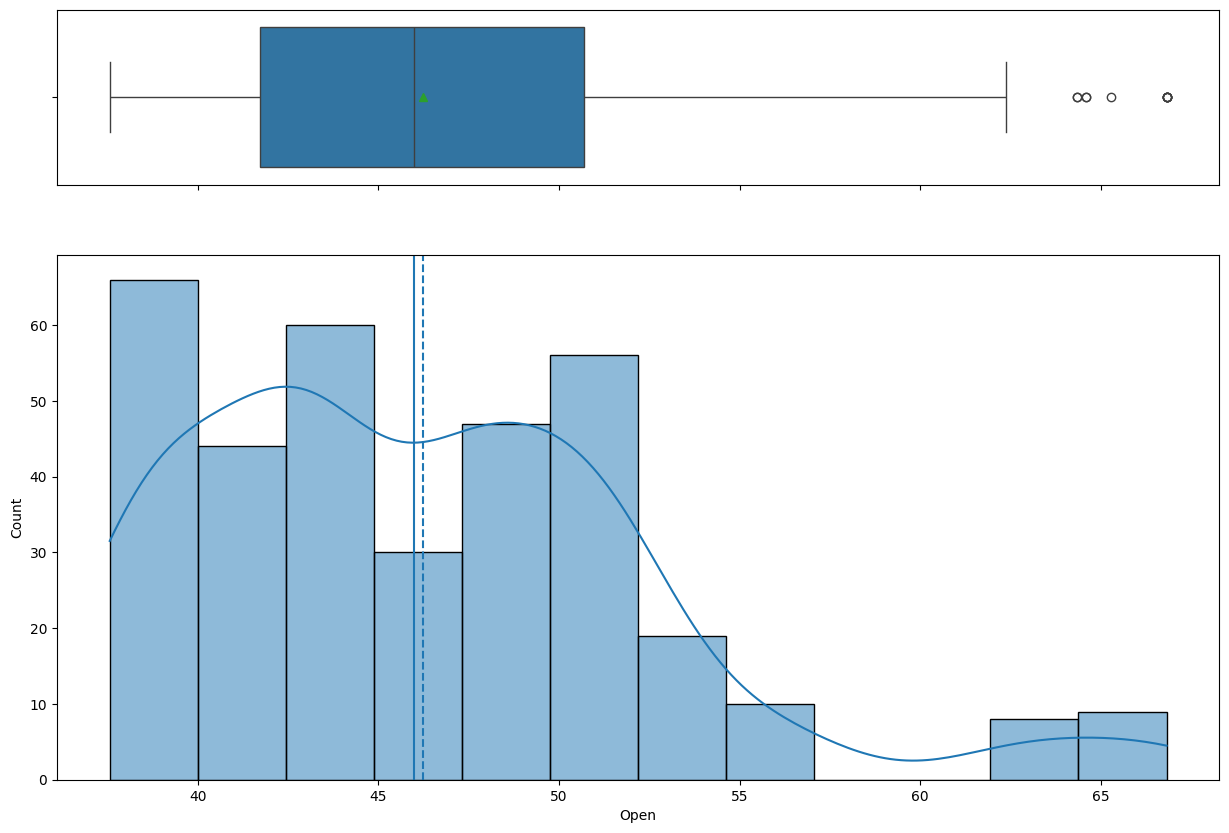

In [21]:
histogram_boxplot(data, "Open", kde=True)

#### Observations:

- Most opening prices fall between **\$40 and \$52**, indicating this is the common trading range.

- The distribution shows a **slight right skew**, with some higher values extending beyond \$60.

- A few **outliers** are present above \$62, which represent unusually high opening prices.


### Distribution of **`High`** *(Numerical Column)*

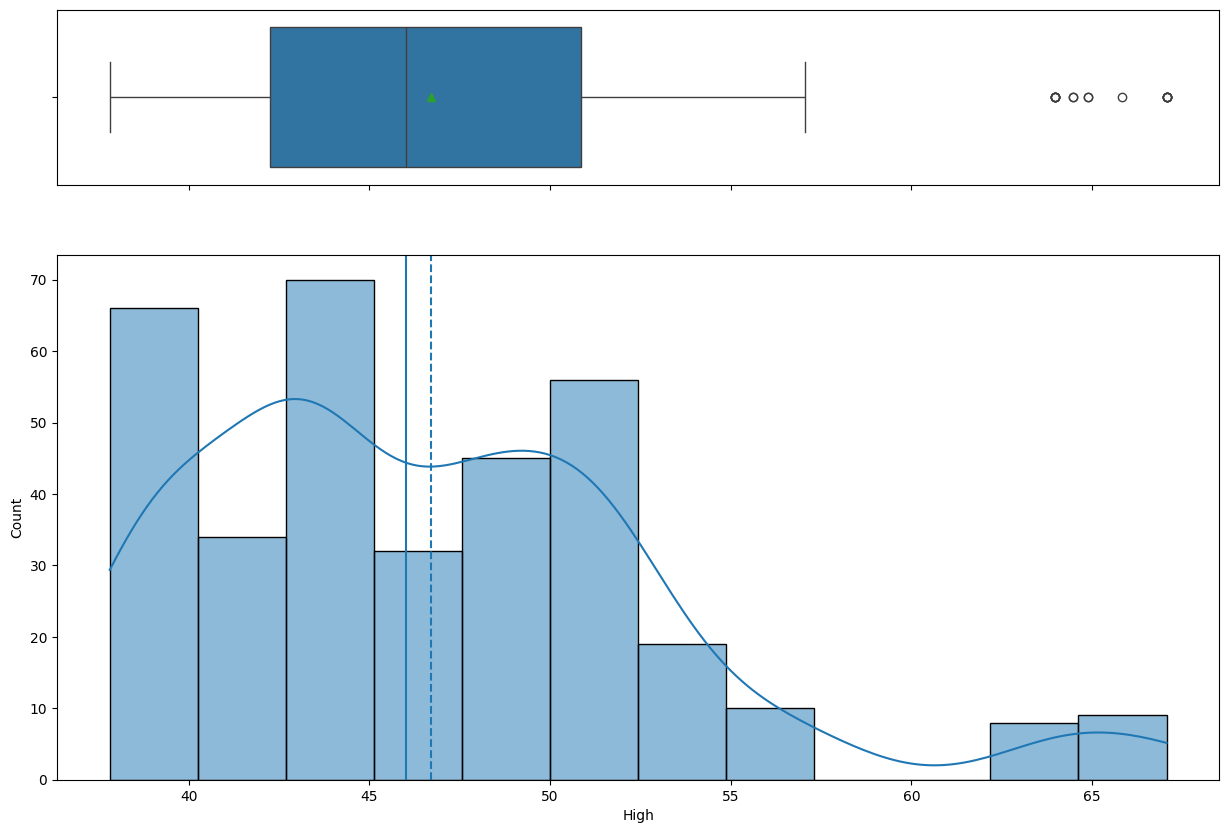

In [22]:
histogram_boxplot(data, "High", kde=True)

#### Observations:

- Most high prices fall between **\$40 and \$52**, which aligns with the general price trend.

- The distribution shows a **slight right skew**, with some prices extending above \$60.

- A few **outliers** are present beyond \$62, indicating days with unusually high price peaks.


### Distribution of **`Low`** *(Numerical Column)*

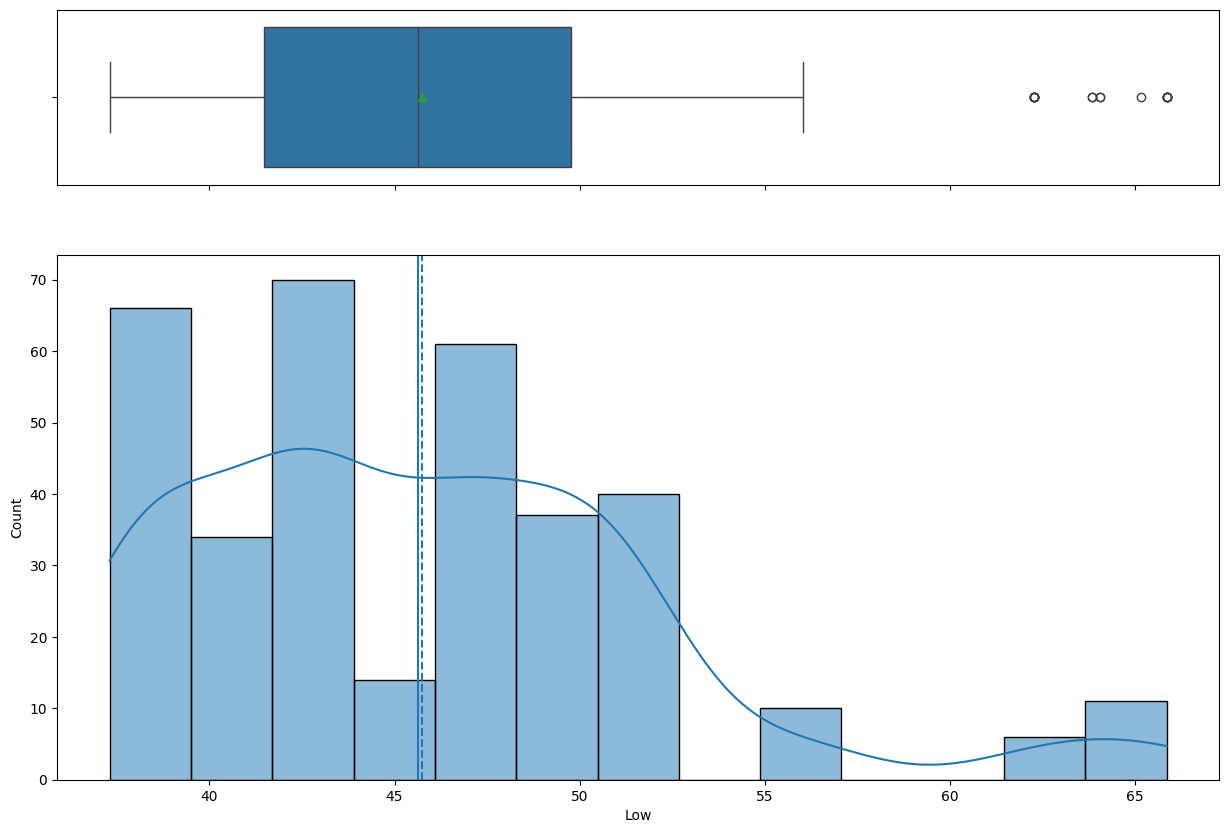

In [23]:
histogram_boxplot(data, "Low", kde=True)

#### Observations:

- Most low prices are concentrated between **\$38 and \$50**, forming the common range for the dataset.

- The distribution exhibits a **slight right skew**, indicating some higher values on the upper end.

- Several **outliers above \$60** are present, suggesting occasional significant price drops compared to typical trading days.


### Distribution of **`Close`** *(Numerical Column)*

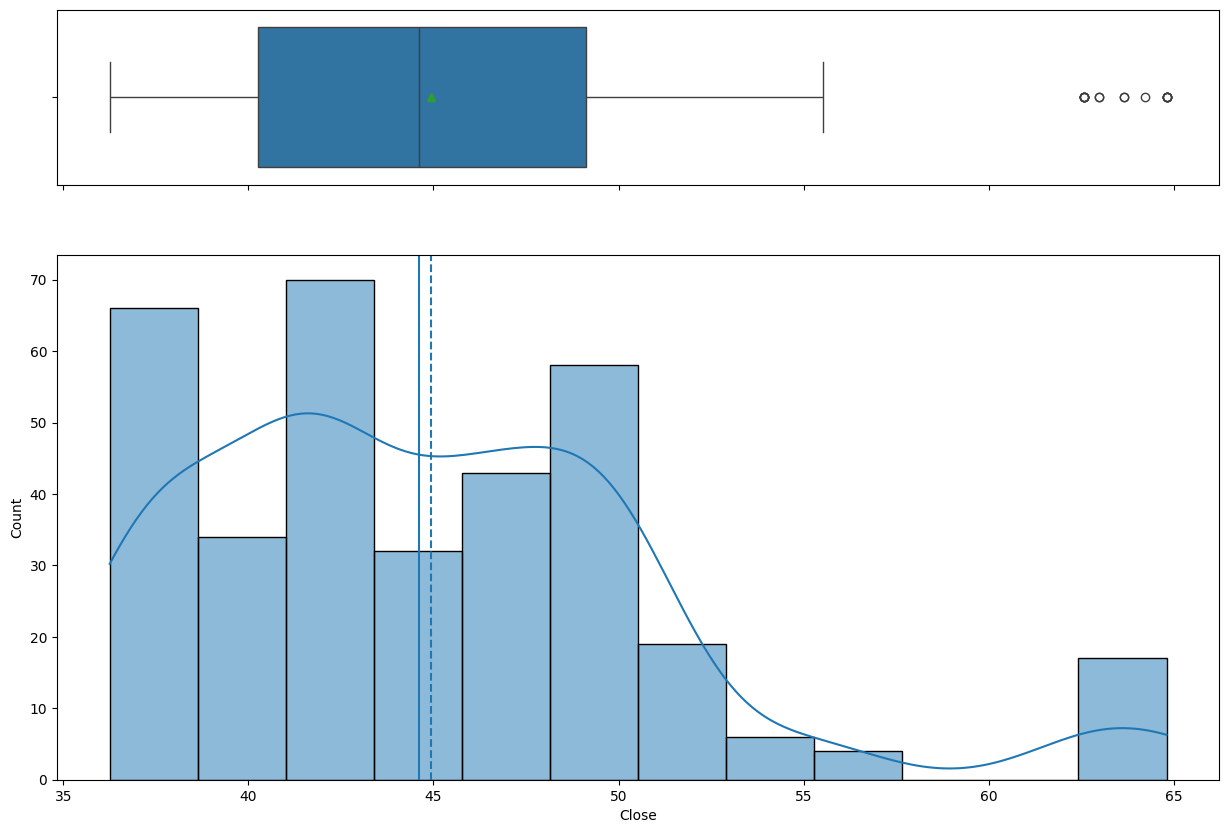

In [24]:
histogram_boxplot(data, "Close", kde=True)

#### Observations:

- The majority of close prices fall in the range of **\$37 to \$50**, which is slightly lower compared to high and open prices.

- The distribution is **right-skewed**, meaning there are fewer higher values above \$55.

- A few **outliers exist beyond \$60**, indicating rare spikes in the closing price.

### Distribution of **`Volume`** *(Numerical Column)*

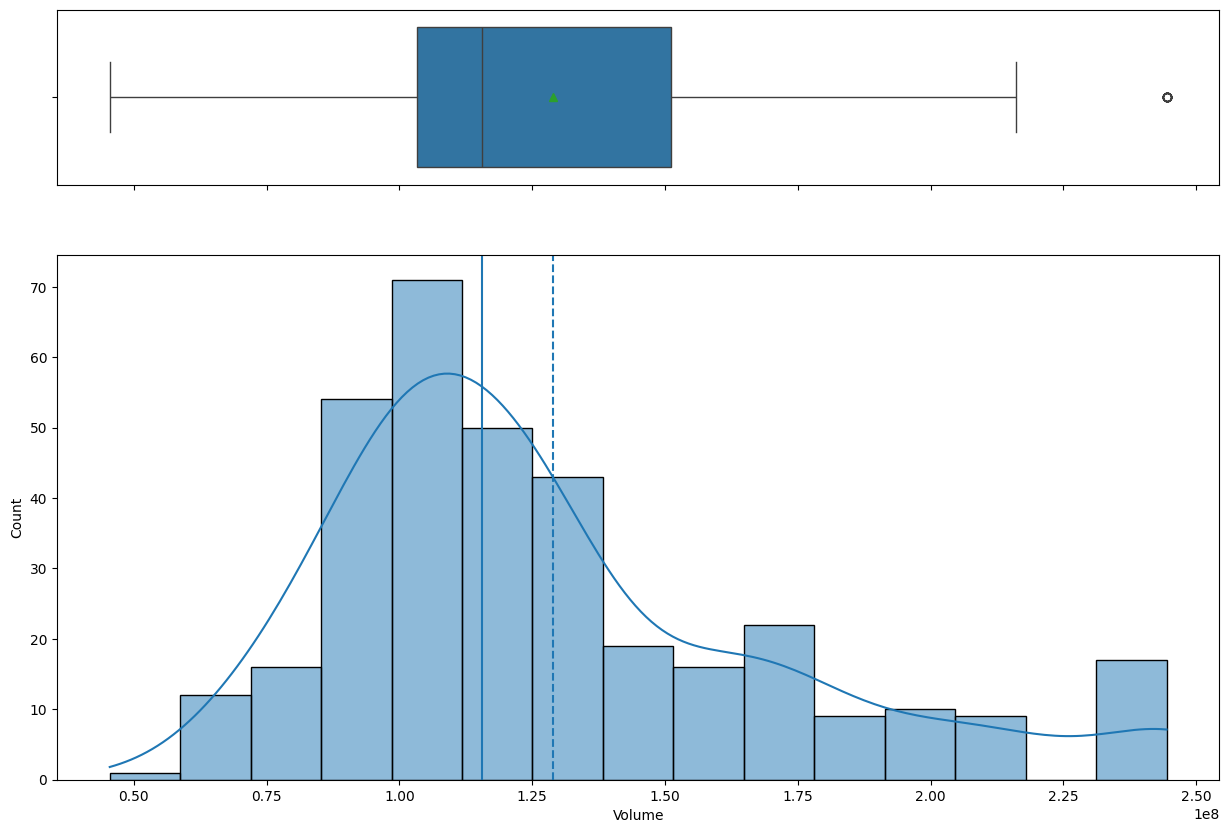

In [25]:
histogram_boxplot(data, "Volume", kde=True)

#### Observations:

- Most trading volumes fall between **90M to 150M**, showing a concentration around this range.

- The distribution is **slightly right-skewed**, indicating a few days with very high trading volumes.

- There is **one significant outlier** near 240M, which represents an unusually high trading day.

### Distribution of **`Label`** *(Categorical Column)*

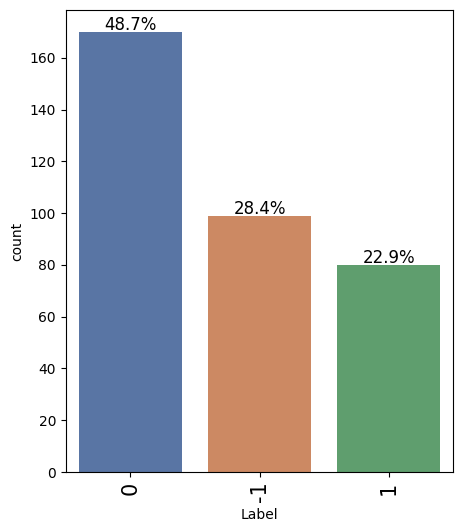

In [26]:
labeled_barplot(data, 'Label', perc=True);

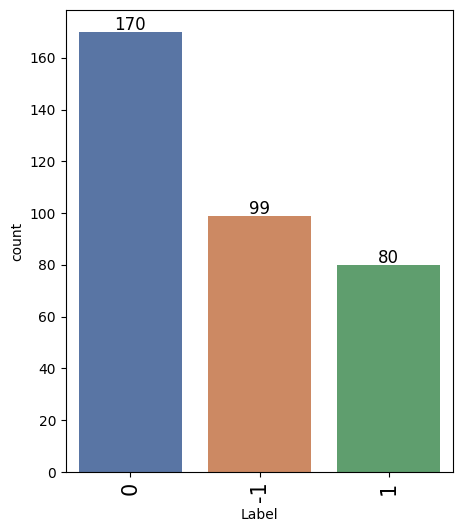

In [27]:
labeled_barplot(data, 'Label');

#### Observations:

- The majority of the labels are **Neutral** with **48.7% (170 observations)**.

- **Negative** labels account for **28.4% (99 observations)**.

- **Positive** labels make up approximately **23% (80 observations)**.

### Distribution of the **`Length of News Content`** *(in Words)*

In [28]:
# Length in terms of words, not characters (since character count can be misleading due to spaces, punctuation, etc.)

data['News_Length'] = data['News'].apply(lambda x: len(x.split()))

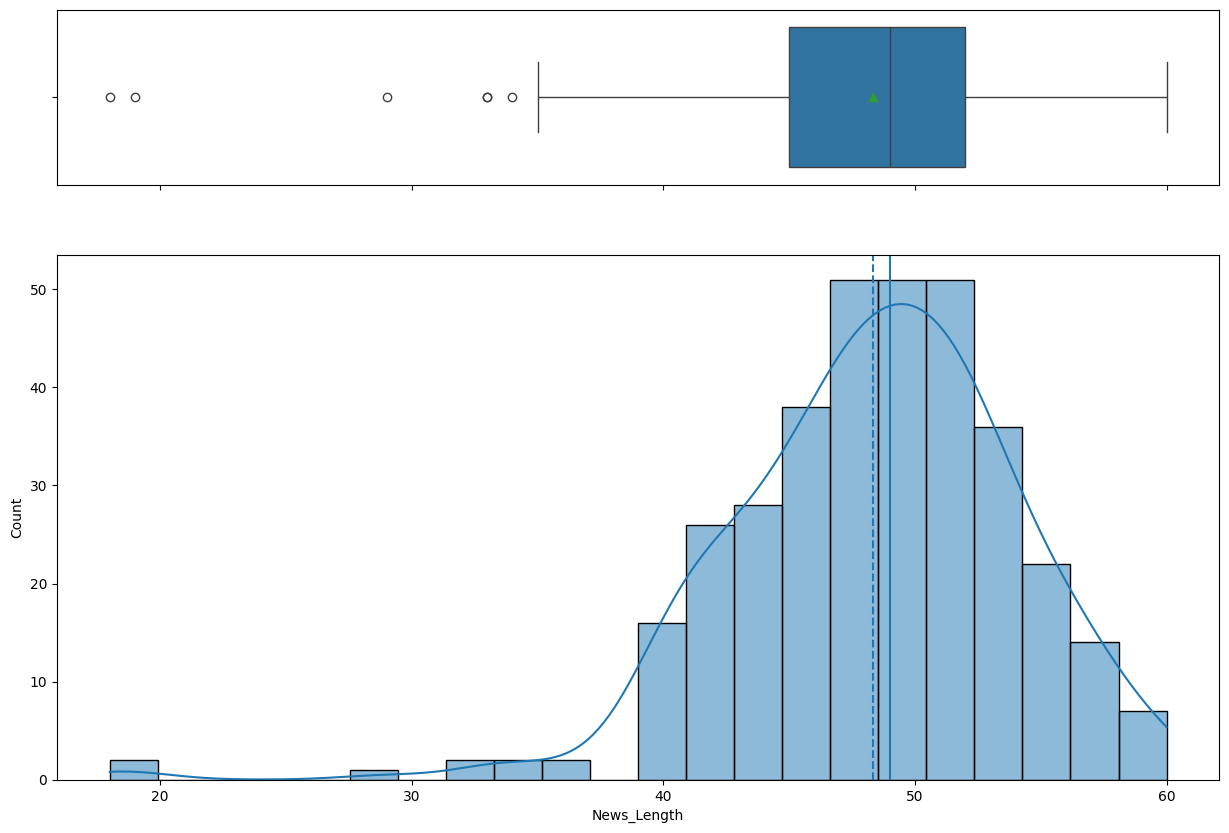

In [29]:
histogram_boxplot(data, "News_Length", kde=True)

#### Observations:

- Most news articles have a length between **40 to 55 words**, and the distribution appears approximately normal.

- A few outliers exist on the lower end (around **18–30 words**), indicating some unusually short news articles.

- The mean and median are very close, suggesting the distribution is **nearly symmetric with minimal skewness**.


## **Bivariate Analysis**

* Correlation
* Sentiment Polarity vs Price
* Date vs Price

**Note**: The above points are listed to provide guidance on how to approach bivariate analysis. Analysis has to be done beyond the above listed points to get maximum scores.

### **Correlation check**

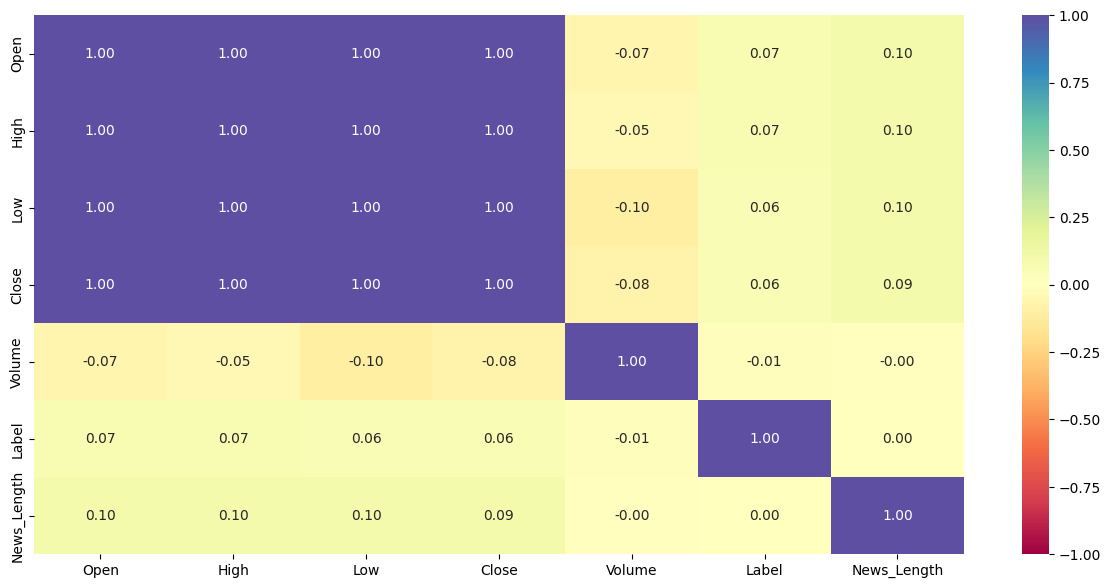

In [30]:
# Heatmap
plt.figure(figsize=(15, 7))
sns.heatmap(data.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

#### **Observations:**

- **Open, High, Low, and Close** prices are perfectly correlated (**correlation = 1.0**), indicating these values move together (possibly redundant features).

- **Volume** shows very weak negative correlation with price columns (around **-0.05 to -0.10**).

- **Label** has very weak positive correlation with price columns (**~0.06 to 0.07**) and no significant correlation with other variables.

- **News_Length** shows a very weak positive correlation (~0.10) with price columns but almost no correlation with Label and Volume.

### Trend of **`Open price`** over Time (**`Date`**)

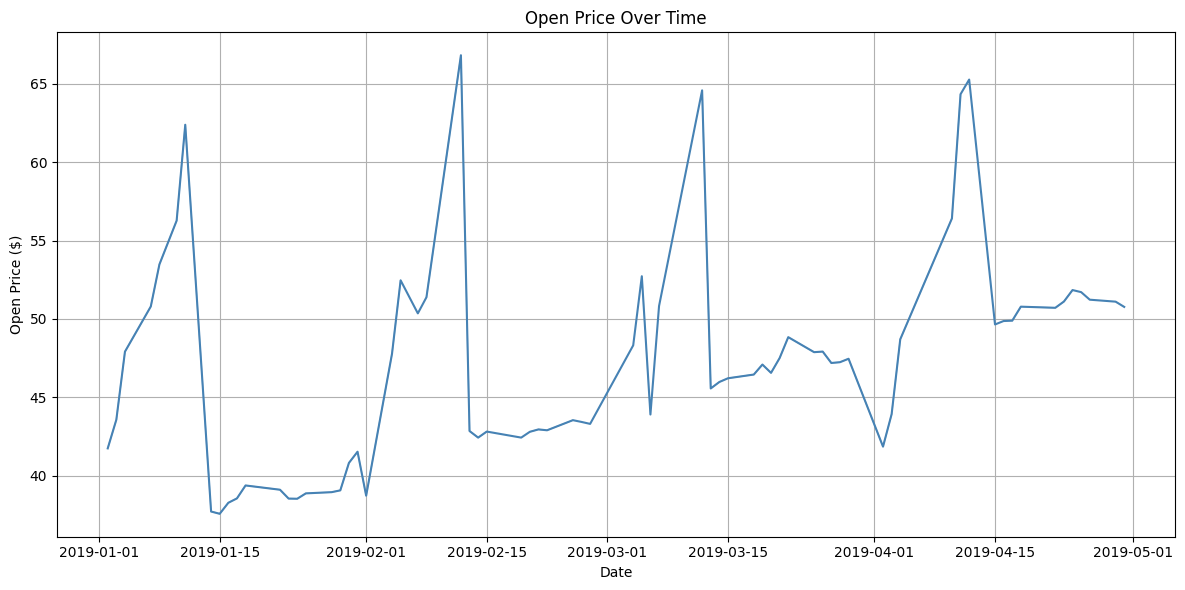

In [31]:
plot_date_vs_price(data, price_col='Open');

#### **Observations:**

- **Highly Volatile Trend:** The Open Price shows high volatility with multiple sharp spikes and drops throughout the observed period.

- **Notable Peaks at Specific Intervals:** Significant peaks are observed around mid-January, mid-February, and mid-April 2019, indicating possible major market events or news during these times.

- **Stabilizing Between Peaks:** Between spikes, the price stabilizes and trends around $40 to $50 before spiking again.

### Trend of **`High price`** over Time (**`Date`**)

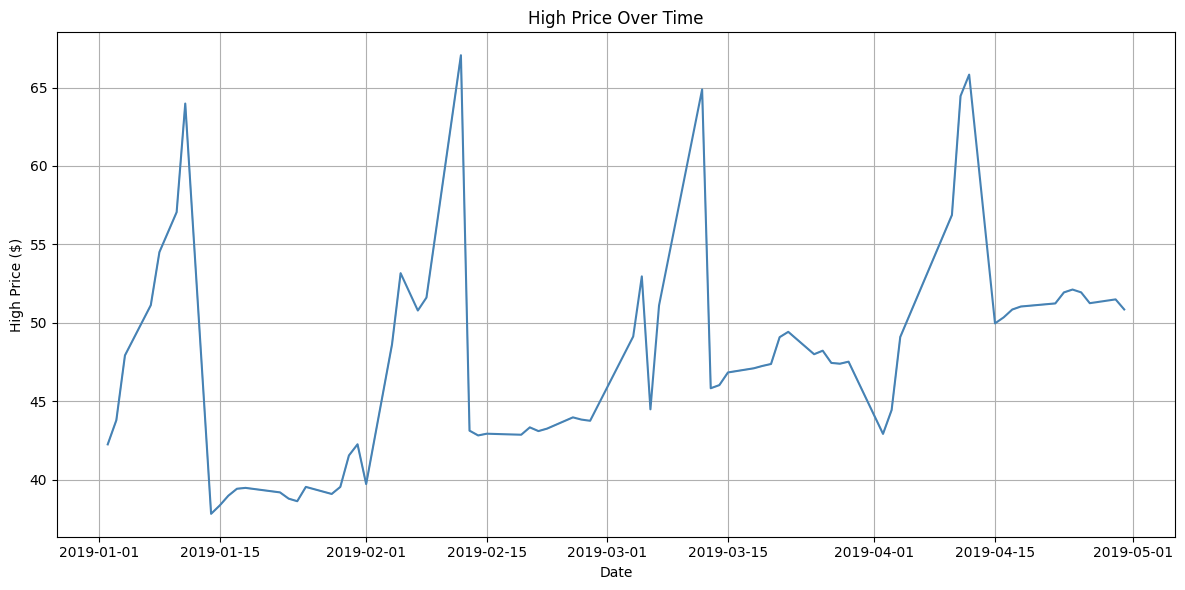

In [32]:
plot_date_vs_price(data, price_col='High')

#### **Observations:**

- **Volatile Pattern Similar to Open Price:** The High Price also exhibits frequent volatility, with sharp peaks similar to the Open Price trend.

- **Major Peaks at Regular Intervals:** Spikes occur around mid-January, mid-February, and mid-April 2019, with values exceeding $60.

- **Stabilization Between Spikes:** Outside of these peaks, prices mostly stabilize between $40 and $50, indicating intermittent surges rather than a sustained trend.

### Trend of **`Low price`** over Time (**`Date`**)

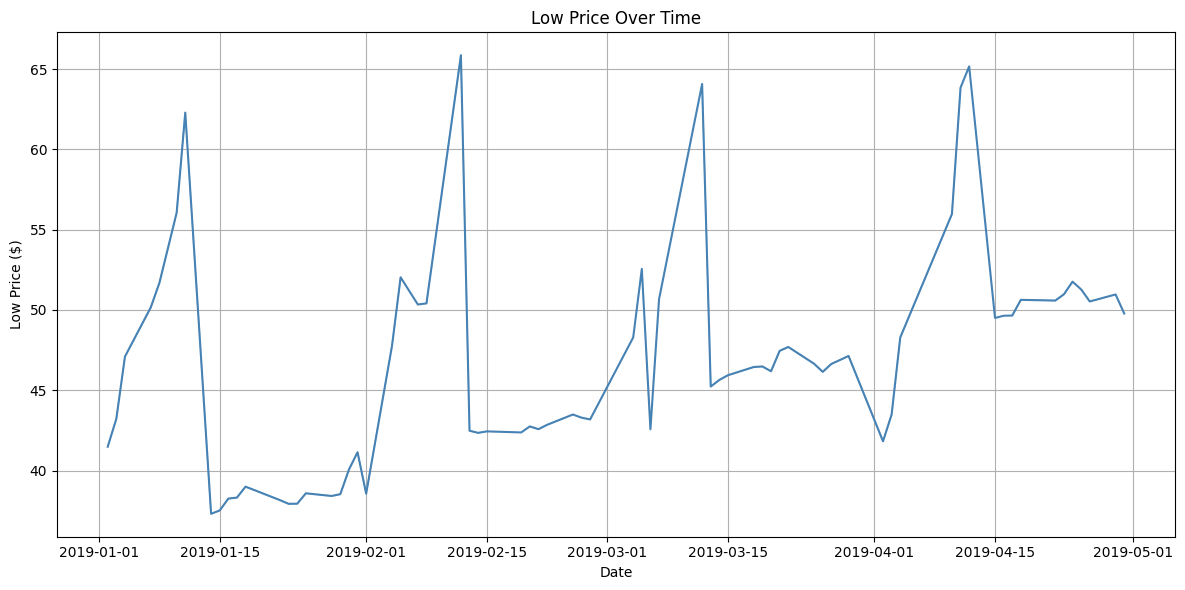

In [33]:
plot_date_vs_price(data, price_col='Low')

#### **Observations:**

- **Mirrors Open and High Price Trends:** The Low Price trend closely mirrors the Open and High price patterns, indicating similar volatility.

- **Spikes at Key Intervals:** Significant spikes occur in mid-January, mid-February, and mid-April 2019, where prices touched above $60.

- **Stable Range Between Peaks:** During stable periods, the Low Price fluctuates between $38 and $50, showing intermittent drops and recoveries.

- **Post-Peak Declines:** A sharp fall follows each major peak, suggesting high short-term volatility.

### Trend of **`Close price`** over Time (**`Date`**)

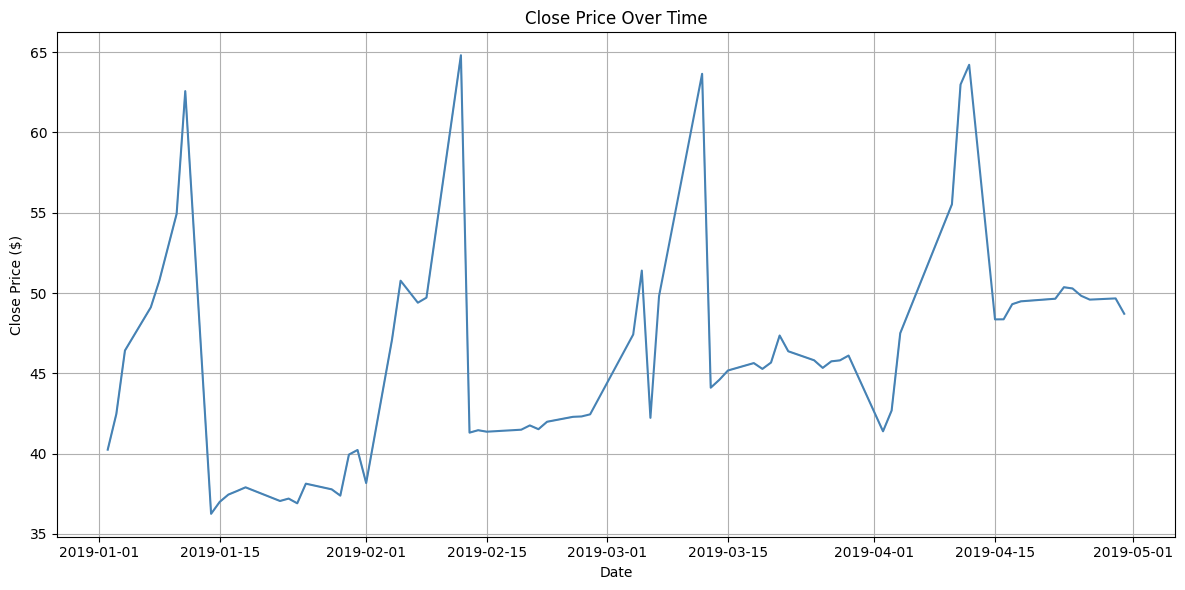

In [34]:
plot_date_vs_price(data, price_col='Close')

#### **Observations:**

- **Sharp Spikes Detected:** The close price jumps to ~65 USD on a few occasions, possibly reacting to major news or market events.

- **Relatively Stable Base:** Apart from spikes, the price mostly hovers between 40–50 USD.

### Trend of **`Volume`** over Time (**`Date`**)

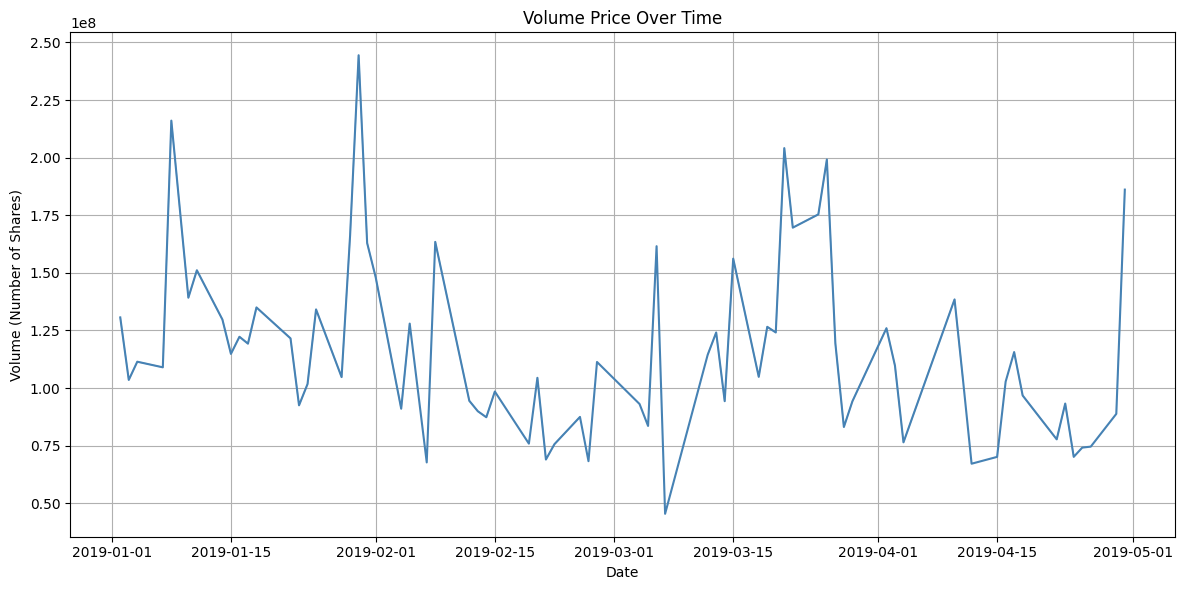

In [35]:
plot_date_vs_price(data, price_col='Volume')

#### **Observations:**

- **High Fluctuation in Volume:** There are several spikes, with volumes reaching nearly 250 million shares—indicating irregular bursts of trading activity.

- **No Clear Trend:** Volume does not show a consistent increasing or decreasing trend over time.

### **`Sentiment Polarity`** vs **`Open Price`**

In [36]:
# data['Label'] = data['Label'].astype(int)
# print(data['Label'].unique())
# print(data['Label'].dtype)

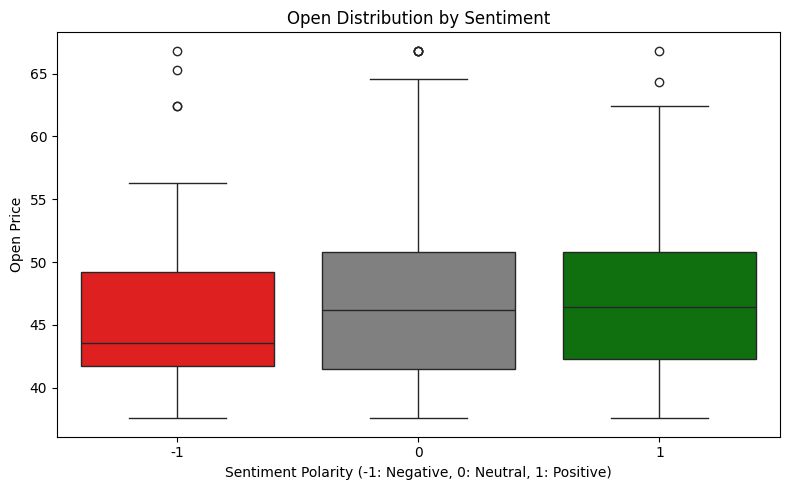

In [37]:
plot_sentiment_vs_price(data, sentiment_col='Label', price_col='Open')

#### **Observations:**

- **Positive Sentiment Shows Higher Median:** The median Open Price increases slightly with positive sentiment, suggesting a mild influence of market sentiment on stock opening price.

- **Neutral Sentiment Has Higher Variability:** Neutral sentiment exhibits a broader price range, indicating higher variability or lack of directional bias.

- **Outliers Across All Sentiments:** Outliers are present in all sentiment categories, highlighting potential news-driven spikes or unusual events impacting stock behavior.


### **`Sentiment Polarity`** vs **`High Price`**

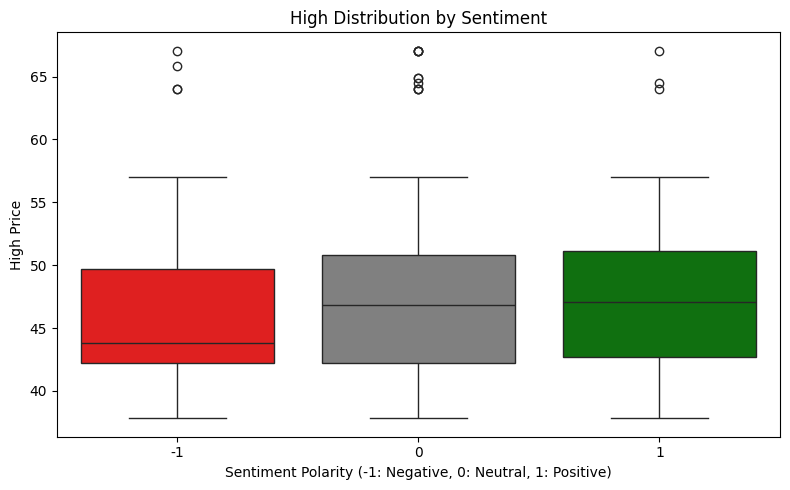

In [38]:
plot_sentiment_vs_price(data, sentiment_col='Label', price_col='High')

#### **Observations:**

- **Positive Sentiment Correlates with Higher Highs:** Median high price under positive sentiment is slightly higher than neutral and negative.

- **Outliers Present Across All Sentiments:** Each sentiment category shows outliers, indicating some extreme price movements.

### **`Sentiment Polarity`** vs **`Low Price`**

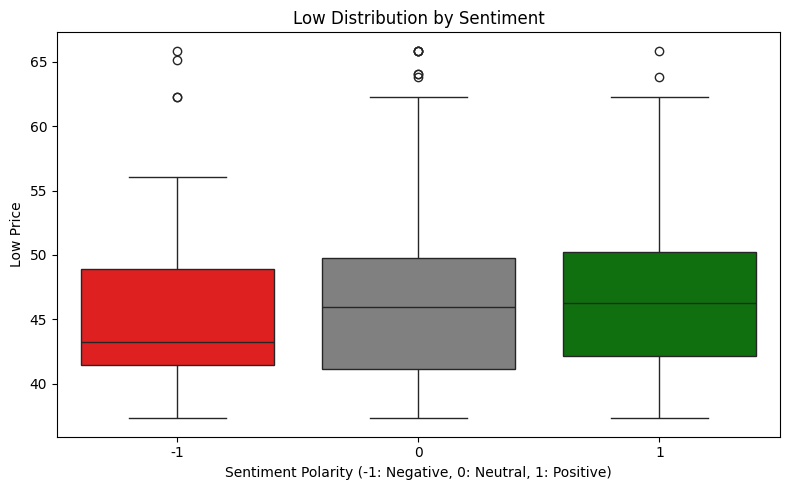

In [39]:
plot_sentiment_vs_price(data, sentiment_col='Label', price_col='Low')

#### **Observations:**

- **Positive Sentiment Has Slightly Higher Lows:** The boxplot for positive sentiment has a higher median low price.

- **Negative Sentiment Shows More Spread:** The interquartile range is wider for negative sentiment, suggesting more variability.

### **`Sentiment Polarity`** vs **`Close Price`**

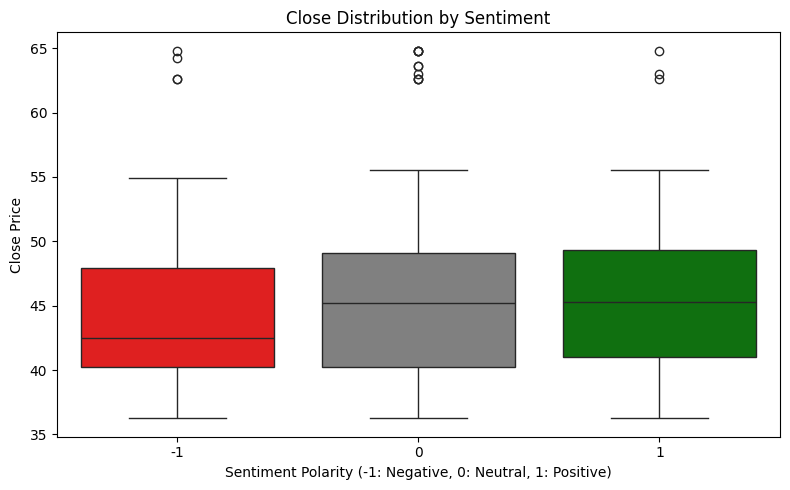

In [40]:
plot_sentiment_vs_price(data, sentiment_col='Label', price_col='Close')

#### **Observations:**

- **Close Price Median Increases with Sentiment:** Negative < Neutral < Positive—indicating sentiment might impact closing prices modestly.

- **High Overlap in Distributions:** Despite some median shifts, the boxplots have similar spreads, suggesting sentiment isn’t the only driver.

# **Data Preprocessing**

In [41]:
dataset = data.copy()

In [42]:
# Loading the Porter Stemmer
ps = PorterStemmer()

In [43]:
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^A-Za-z\s]', '', text)

    # Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Split text into separate words
    words = text.split()

    # Removing English language stopwords
    text = ' '.join([word for word in words if word not in stopwords.words('english')])

    words = text.split()

    # Applying the Porter Stemmer on every word of a message and joining the stemmed words back into a single string
    text = ' '.join([ps.stem(word) for word in words])

    return text

In [44]:
# preprocessing the textual column
dataset['News_text_clean'] = dataset['News'].apply(preprocess_text)

In [45]:
dataset.iloc[:, [1, 10]]

,News,News_text_clean
0,"The tech sector experienced a significant decline in the aftermarket following Apple's Q1 revenue warning. Notable suppliers, including Skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple's downward revision of its revenue expectations for the quarter, previously announced in January.",tech sector experienc signific declin aftermarket follow appl q revenu warn notabl supplier includ skywork broadcom lumentum qorvo tsmc saw stock drop respons appl downward revis revenu expect quarter previous announc januari
1,"Apple lowered its fiscal Q1 revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales. The announcement caused a significant drop in Apple's stock price and negatively impacted related suppliers, leading to broader market declines for tech indices such as Nasdaq 10",appl lower fiscal q revenu guidanc billion earlier estim billion due weaker expect iphon sale announc caus signific drop appl stock price neg impact relat supplier lead broader market declin tech indic nasdaq
2,"Apple cut its fiscal first quarter revenue forecast from $89-$93 billion to $84 billion due to weaker demand in China and fewer iPhone upgrades. CEO Tim Cook also mentioned constrained sales of Airpods and Macbooks. Apple's shares fell 8.5% in post market trading, while Asian suppliers like Hon",appl cut fiscal first quarter revenu forecast billion billion due weaker demand china fewer iphon upgrad ceo tim cook also mention constrain sale airpod macbook appl share fell post market trade asian supplier like hon
3,"This news article reports that yields on long-dated U.S. Treasury securities hit their lowest levels in nearly a year on January 2, 2019, due to concerns about the health of the global economy following weak economic data from China and Europe, as well as the partial U.S. government shutdown. Apple",news articl report yield longdat us treasuri secur hit lowest level nearli year januari due concern health global economi follow weak econom data china europ well partial us govern shutdown appl
4,"Apple's revenue warning led to a decline in USD JPY pair and a gain in Japanese yen, as investors sought safety in the highly liquid currency. Apple's underperformance in Q1, with forecasted revenue of $84 billion compared to analyst expectations of $91.5 billion, triggered risk aversion mood in markets",appl revenu warn led declin usd jpi pair gain japanes yen investor sought safeti highli liquid currenc appl underperform q forecast revenu billion compar analyst expect billion trigger risk avers mood market
...,...,...
344,"Media mogul Oprah Winfrey, known for influencing millions with her opinions on diets and books, is considering which Democratic presidential candidate to endorse in 2020. She told the Hollywood Reporter she's ""quietly figuring out where I'm going to use my voice"" and will make a clear announcement",media mogul oprah winfrey known influenc million opinion diet book consid democrat presidenti candid endors told hollywood report she quietli figur im go use voic make clear announc
345,"European shares fell on Tuesday, with banks underperforming amid a decline in China's manufacturing activity and awaiting euro zone economic growth numbers. The pan-European STOXX 600 index dropped 0.7% while major indices fell except London's FTSE 100. Danske Bank plunged",european share fell tuesday bank underperform amid declin china manufactur activ await euro zone econom growth number paneuropean stoxx index drop major indic fell except london ftse dansk bank plung
346,"This article reports that the S&P 500 reached another record high close on Tuesday, marking its best four-month stretch since late 2010. Apple's strong quarterly results and positive earnings forecast helped ease concerns about the bull run's sustainability, despite a revenue miss from Google parent Alphabet. The",articl report sp reach anoth record high close tues

### **Split the target variable and predictors** & **Split the data into train, validation, and test sets**

#### **We Use Date-Based Splitting Instead of Random Splitting:**

- In time-sensitive datasets like financial news and stock prices, information is sequentially dependent on dates.

- Random splitting can cause data leakage, where future data ends up in the training set, leading to unrealistic performance.

- By splitting based on Date, we simulate a real-world scenario where the model only learns from past data to predict future outcomes.

- This approach improves the reliability and generalization of the model, especially for tasks involving trend forecasting or time-aware predictions.

In [46]:
# Split data based on date
X_train = data[data['Date'] < '2019-04-01'].reset_index(drop=True)
X_val = data[(data['Date'] >= '2019-04-01') & (data['Date'] < '2019-04-16')].reset_index(drop=True)
X_test = data[data['Date'] >= '2019-04-16'].reset_index(drop=True)

# Extract target variable
Y_train = X_train["Label"].copy()
Y_val = X_val["Label"].copy()
Y_test = X_test["Label"].copy()

# Check shape
print("Train data shape:", X_train.shape)
print("Validation data shape:", X_val.shape)
print("Test data shape:", X_test.shape)

print("Train label shape:", Y_train.shape)
print("Validation label shape:", Y_val.shape)
print("Test label shape:", Y_test.shape)

Train data shape: (286, 10)
Validation data shape: (21, 10)
Test data shape: (42, 10)
Train label shape: (286,)
Validation label shape: (21,)
Test label shape: (42,)


# **Word Embeddings**

## **Model Support Function**

In [47]:
def print_dataset_info(model_name, train_features, val_features, test_features, y_train, y_val, y_test):
    """
    Prints the shape of train, validation, and test feature sets along with
    class distribution for training, validation, and test sets.

    Parameters:
    - model_name: str, name of the embedding/model (e.g., 'Word2Vec', 'GloVe', 'Sentence Transformer')
    - train_features: DataFrame or array for training features
    - val_features: DataFrame or array for validation features
    - test_features: DataFrame or array for test features
    - y_train, y_val, y_test: Series containing labels for each set
    """

    print(f"=== {model_name} ===")
    print(f"Shape of the Training set (features): {train_features.shape}")
    print(f"Shape of the Validation set (features): {val_features.shape}")
    print(f"Shape of the Test set (features): {test_features.shape}")
    print()
    print("-" * 50)

    print("Percentage of Classes in Training Set:")
    print(y_train.value_counts(normalize=True) * 100)
    print()
    print("-" * 50)

    print("Percentage of Classes in Validation Set:")
    print(y_val.value_counts(normalize=True) * 100)
    print()
    print("-" * 50)

    print("Percentage of Classes in Test Set:")
    print(y_test.value_counts(normalize=True) * 100)
    print("\n" + "=" * 70 + "\n")

## **Using Word2Vec**

In [48]:
# Creating a list of all words in our data
words_list = [item.split(" ") for item in dataset['News_text_clean'].values]

In [49]:
# Creating an instance of Word2Vec
vec_size = 300
model_W2V = Word2Vec(words_list, vector_size = vec_size, min_count = 1, window=5, workers = 6)

In [50]:
# Checking the size of the vocabulary
print("Length of the vocabulary is", len(list(model_W2V.wv.key_to_index)))

Length of the vocabulary is 2497


### Let's check out a few word embeddings obtained using the model.

In [51]:
# Checking the word embedding of a random word
word = "market"
model_W2V.wv[word]

array([-2.07860000e-03,  8.61784443e-03,  1.49470859e-03,  7.18696974e-03,
       -2.66667432e-03, -1.03299282e-02,  8.41366127e-03,  1.63035505e-02,
        2.47742701e-03,  5.76404040e-04, -2.56955787e-03, -1.14273485e-02,
        2.05415208e-03, -4.43163421e-03, -8.57879966e-03, -8.14108923e-03,
        3.15753650e-03, -2.35454366e-03,  5.03629399e-03, -5.13268914e-03,
       -1.63226109e-03, -3.74191394e-03,  5.12600737e-03,  2.24902714e-03,
        7.05217710e-03,  1.11984543e-03, -1.11646131e-02, -3.04718618e-04,
       -7.19422102e-03, -1.24152843e-02,  5.01947245e-03, -2.36181938e-03,
        2.87303049e-03, -1.88929797e-03, -1.46766473e-03, -2.23708129e-03,
        5.08829905e-03, -7.67947361e-03, -2.39536120e-03,  2.82873563e-03,
       -5.77566633e-03, -3.29823419e-03,  3.06218542e-04, -5.57255885e-03,
        1.70182844e-03,  5.27043734e-03,  6.35020481e-03,  2.73479847e-03,
       -1.24067080e-03,  8.03346466e-03,  1.39431946e-03,  1.33658398e-03,
       -2.23644986e-03,  

In [52]:
# Checking top 5 similar words to the word 'market' using Cosine Similarity
similar = model_W2V.wv.similar_by_word('market', topn=5)
print(similar)

[('appl', 0.9283506870269775), ('compani', 0.9153839349746704), ('report', 0.9027566909790039), ('trade', 0.8979681730270386), ('includ', 0.89730304479599)]


In [53]:
similar = model_W2V.wv.similar_by_word('revenu', topn=5)
print(similar)

[('appl', 0.909675657749176), ('compani', 0.8979435563087463), ('due', 0.8878944516181946), ('report', 0.8864920139312744), ('stock', 0.8864474296569824)]


In [54]:
similar = model_W2V.wv.similar_by_word('stock', topn=5)
print(similar)

[('appl', 0.9305042624473572), ('due', 0.9131309390068054), ('compani', 0.9113911986351013), ('report', 0.910219669342041), ('year', 0.9042168855667114)]


### Word2Vec model's vocabulary

In [55]:
# Retrieving the words present in the Word2Vec model's vocabulary
words = list(model_W2V.wv.key_to_index.keys())

# Retrieving word vectors for all the words present in the model's vocabulary
wvs = model_W2V.wv[words].tolist()

# Creating a dictionary of words and their corresponding vectors
word_vector_dict = dict(zip(words, wvs))

In [56]:
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [57]:
# creating a dataframe of the vectorized documents
df_Word2Vec_train = pd.DataFrame(X_train['News'].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
df_Word2Vec_val = pd.DataFrame(X_val['News'].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
df_Word2Vec_test = pd.DataFrame(X_test['News'].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])

In [58]:
# For Word2Vec
print_dataset_info("Word2Vec", df_Word2Vec_train, df_Word2Vec_val, df_Word2Vec_test, Y_train, Y_val, Y_test)

=== Word2Vec ===
Shape of the Training set (features): (286, 300)
Shape of the Validation set (features): (21, 300)
Shape of the Test set (features): (42, 300)

--------------------------------------------------
Percentage of Classes in Training Set:
Label
 0    48.251748
-1    28.671329
 1    23.076923
Name: proportion, dtype: float64

--------------------------------------------------
Percentage of Classes in Validation Set:
Label
 0    57.142857
 1    23.809524
-1    19.047619
Name: proportion, dtype: float64

--------------------------------------------------
Percentage of Classes in Test Set:
Label
 0    47.619048
-1    30.952381
 1    21.428571
Name: proportion, dtype: float64




In [59]:
df_Word2Vec_train

,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,...,Feature 290,Feature 291,Feature 292,Feature 293,Feature 294,Feature 295,Feature 296,Feature 297,Feature 298,Feature 299
0,-0.000653,0.004746,-0.000229,0.002219,-0.000164,-0.004133,0.002945,0.006469,0.000589,-0.001313,...,0.000428,0.003799,0.002600,0.000659,0.004081,0.003945,0.001640,-0.001227,0.003086,-0.001207
1,-0.001665,0.005576,0.000442,0.002691,-0.000397,-0.006148,0.004590,0.011750,0.001779,-0.001625,...,0.000500,0.006380,0.004620,0.001301,0.005644,0.006409,0.000974,-0.003879,0.003161,-0.000136
2,-0.001896,0.004396,0.002123,0.002845,-0.000845,-0.006133,0.004284,0.010385,0.000354,-0.000826,...,0.000104,0.005923,0.004670,0.000678,0.004047,0.005024,0.000578,-0.003594,0.004098,-0.000610
3,-0.000163,0.004613,0.000502,0.002334,-0.000120,-0.005357,0.002596,0.009207,0.000572,-0.000157,...,0.000454,0.004832,0.003759,0.001057,0.003820,0.005197,0.000886,-0.002728,0.001982,-0.001989
4,-0.001283,0.002607,0.000072,0.002115,-0.000347,-0.004435,0.001031,0.005928,0.001063,-0.000444,...,-0.000026,0.003482,0.002151,0.000698,0.002684,0.002867,-0.000624,-0.002938,0.001645,-0.000128
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281,-0.001657,0.002540,-0.000538,0.000273,0.001296,-0.004270,0.003702,0.005462,0.000397,-0.002761,...,-0.000069,0.004922,0.000950,-0.000141,0.002533,0.002633,-0.000502,-0.003347,0.002102,-0.000015
282,-0.001595,0.005334,0.001197,0.002703,-0.000550,-0.005655,0.003443,0.011067,0.001600,0.000426,...,0.001168,0.005754,0.004405,0.001059,0.004673,0.006410,0.001004,-0.002555,0.002732,-0.000460
283,-0.001627,0.003196,-0.000062,0.002337,0.000737,-0.003967,0.002198,0.007115,0.000224,-0.001063,...,-0.000319,0.003708,0.002463,0.000106,0.003566,0.002654,0.001178,-0.002265,0.002387,-0.000518
284,-0.002517,0.004142,0.000261,0.001771,0.000620,-0.002470,0.002422,0.006022,0.000723,-0.000745,...,0.000507,0.003615,0.002734,0.000345,0.003437,0.004854,0.000867,-0.000623,0.001073,-0.000355


## **Using GloVe**

In [ ]:
glove_input_file = '/content/drive/MyDrive/NLP/glove.6B.100d.txt'
word2vec_output_file = '/content/drive/MyDrive/NLP/glove.6B.100d.txt.word2vec'
glove2word2vec(glove_input_file, word2vec_output_file)

(400000, 100)

In [61]:
from gensim.models import KeyedVectors
glove_model = KeyedVectors.load_word2vec_format(word2vec_output_file, binary=False)

In [62]:
# Checking the size of the vocabulary
print("Length of the vocabulary is", len(glove_model.index_to_key))

Length of the vocabulary is 400000


### Let's check out a few word embeddings obtained using the model.

In [63]:
# Checking the word embedding of a random word
word = "market"
glove_model[word]

array([ 0.39093  ,  0.23755  ,  0.44855  ,  0.11237  , -0.25996  ,
       -1.2248   , -0.44237  , -0.53491  ,  0.37142  , -0.61981  ,
       -0.27387  , -0.032213 ,  0.082629 , -0.52986  ,  0.13012  ,
        0.21703  , -0.45026  , -0.0048895,  0.34887  , -0.26069  ,
        0.56598  , -0.36219  ,  0.41926  ,  0.23441  , -0.29407  ,
       -0.27044  ,  0.29339  , -0.73905  , -0.75965  ,  0.64661  ,
       -0.038757 ,  0.38495  , -0.32314  ,  0.040322 ,  0.24036  ,
        0.35167  ,  0.47404  ,  0.014959 ,  0.12105  , -1.0398   ,
        0.27639  , -1.3785   , -0.22851  , -0.098074 ,  0.1495   ,
       -0.2815   ,  0.31682  , -0.10208  , -0.08586  , -1.5114   ,
       -0.48255  ,  0.15131  ,  0.0080133,  0.74594  , -0.20163  ,
       -2.5268   , -0.82083  ,  0.1143   ,  2.4665   ,  0.19841  ,
        0.1146   ,  0.10083  , -0.60936  ,  0.76722  ,  0.025978 ,
       -0.036936 ,  0.46744  , -0.77073  ,  0.83992  , -0.032931 ,
       -0.13127  , -0.097367 , -0.42634  , -0.49478  , -0.4079

In [64]:
result = glove_model.most_similar("market", topn=5)
print(result)

[('markets', 0.8939464092254639), ('stock', 0.7991609573364258), ('prices', 0.7834224700927734), ('stocks', 0.7668591737747192), ('investors', 0.7563610076904297)]


In [65]:
result = glove_model.most_similar("stock", topn=5)
print(result)

[('shares', 0.8525474667549133), ('stocks', 0.8309943079948425), ('market', 0.7991610765457153), ('exchange', 0.784952700138092), ('trading', 0.7632874846458435)]


In [66]:
glove_words = glove_model.index_to_key

In [67]:
glove_word_vector_dict = dict(zip(glove_model.index_to_key,list(glove_model.vectors)))
# glove_word_vector_dict

In [68]:
vec_size=100

In [69]:
def average_vectorizer_GloVe(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in glove_words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(glove_word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [70]:
# creating a dataframe of the vectorized documents
df_Glove_train = pd.DataFrame(X_train['News'].apply(average_vectorizer_GloVe).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
df_Glove_val = pd.DataFrame(X_val['News'].apply(average_vectorizer_GloVe).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
df_Glove_test = pd.DataFrame(X_test['News'].apply(average_vectorizer_GloVe).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])

In [71]:
# For GloVe
print_dataset_info("GloVe", df_Glove_train, df_Glove_val, df_Glove_test,  Y_train, Y_val, Y_test)

=== GloVe ===
Shape of the Training set (features): (286, 100)
Shape of the Validation set (features): (21, 100)
Shape of the Test set (features): (42, 100)

--------------------------------------------------
Percentage of Classes in Training Set:
Label
 0    48.251748
-1    28.671329
 1    23.076923
Name: proportion, dtype: float64

--------------------------------------------------
Percentage of Classes in Validation Set:
Label
 0    57.142857
 1    23.809524
-1    19.047619
Name: proportion, dtype: float64

--------------------------------------------------
Percentage of Classes in Test Set:
Label
 0    47.619048
-1    30.952381
 1    21.428571
Name: proportion, dtype: float64




In [72]:
df_Glove_train

,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,...,Feature 90,Feature 91,Feature 92,Feature 93,Feature 94,Feature 95,Feature 96,Feature 97,Feature 98,Feature 99
0,-0.005744,0.065034,0.198916,-0.053848,0.107719,-0.286855,-0.224428,0.067162,-0.236218,0.081928,...,0.067063,0.031508,-0.376078,0.061713,-0.533375,0.040044,-0.072857,-0.161835,0.672949,-0.018650
1,0.043671,0.241691,0.250482,0.006381,0.090243,-0.413783,-0.244261,-0.036884,-0.213101,0.066538,...,0.025986,0.126922,-0.372906,-0.198931,-0.539055,0.162539,0.029252,-0.223735,0.662147,-0.062919
2,0.111154,0.201604,0.362837,-0.062324,0.167741,-0.372270,-0.232135,0.043971,-0.185100,0.052883,...,0.081615,0.095182,-0.243225,-0.196940,-0.718021,0.137351,0.026241,-0.125204,0.742984,-0.099995
3,-0.066261,0.089031,0.413866,-0.067818,0.060751,-0.180289,-0.301159,0.010046,-0.224764,-0.004630,...,0.070485,0.062053,-0.346016,0.172000,-0.515252,0.101617,-0.087951,-0.325129,0.637759,0.050585
4,-0.010394,0.058511,0.284072,-0.051692,0.105441,-0.144257,-0.191704,-0.123280,-0.279425,0.134444,...,0.100656,0.021943,-0.301703,-0.033465,-0.389536,0.165580,-0.039467,-0.204008,0.446459,0.016644
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281,0.184158,0.207087,0.241934,-0.090630,0.112527,-0.340006,-0.214691,0.032866,-0.377465,-0.095730,...,-0.112606,-0.101697,-0.227472,0.452985,-0.802858,0.324642,-0.047719,-0.195857,0.657681,0.078163
282,0.000202,0.034362,0.298902,-0.032927,0.078958,-0.185992,-0.165056,0.202227,-0.165757,0.118965,...,-0.025093,0.096685,-0.206941,0.067871,-0.414070,0.116139,0.009666,-0.177279,0.765460,0.009956
283,-0.000620,0.060687,0.296143,-0.233633,0.371407,-0.082654,-0.109179,0.027201,-0.361921,0.029665,...,0.075620,-0.082617,-0.250497,0.178106,-0.380776,0.041556,-0.125614,-0.264388,0.736678,0.023817
284,-0.042023,0.036042,0.285216,-0.068454,0.242802,-0.269770,-0.166889,-0.057931,-0.059976,0.016741,...,-0.065148,-0.022918,-0.415174,0.006820,-0.235481,0.226504,-0.189587,-0.227200,0.794641,0.152241


## **Using Sentence Transformer**

In [73]:
#Defining the model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [74]:
model.encode(["hello, I'm from India!"])

array([[ 1.35147143e-02, -2.34892424e-02,  3.42103988e-02,
         4.97822650e-03,  8.98198690e-03, -8.40926617e-02,
         5.73997498e-02, -7.75395939e-03, -2.45320867e-03,
        -1.53156407e-02,  2.15710681e-02, -1.50055131e-02,
         3.70096043e-02, -5.00388108e-02,  1.91495791e-02,
        -6.64252043e-02,  2.92815715e-02, -6.36458993e-02,
         1.28779160e-02, -3.93305346e-03,  2.08609551e-02,
         8.72603580e-02,  2.89878552e-03,  3.50340940e-02,
         2.30720136e-02, -5.04749035e-03,  8.73375610e-02,
         2.05324665e-02,  9.61767882e-03, -3.49504575e-02,
         5.77190407e-02,  5.83487898e-02, -3.72762121e-02,
         4.52601351e-02,  3.59021430e-03,  5.94050363e-02,
        -6.81701228e-02, -3.36667188e-02,  3.34651060e-02,
         4.03755717e-02,  1.54618537e-02,  2.15361323e-02,
         3.37221734e-02, -1.00581869e-02,  5.39703257e-02,
         9.78861935e-03,  6.62425300e-04,  1.02624469e-01,
         1.09908718e-03,  8.76543205e-03, -4.23684157e-0

In [75]:
# defining a function to compute the cosine similarity between two embedding vectors
def cosine_score(text):
    # encoding the text
    embeddings = model.encode(text)

    # calculating the L2 norm of the embedding vector
    norm1 = np.linalg.norm(embeddings[0])
    norm2 = np.linalg.norm(embeddings[1])

    # computing the cosine similarity
    cosine_similarity_score = ((np.dot(embeddings[0],embeddings[1]))/(norm1*norm2))

    return cosine_similarity_score

### Let's check out a few sentence embeddings and their similarity scores obtained using the model

In [76]:
sentence_1 = "The cat is on the mat."
sentence_2 = "The mat has a cat on it."

cosine_score([sentence_1, sentence_2])

0.9624442

#### Observations:
- The **high cosine similarity score** indicates that the sentences are **semantically similar**.


In [77]:
sentence_1 = "Roses are red, violets are blue."
sentence_2 = "The Earth orbits the Sun in our solar system."

cosine_score([sentence_1, sentence_2])

0.12664366

#### Observations:
- The **low cosine similarity score** indicates that the sentences are **semantically dissimilar**.

In [78]:
sentence_1 = "My name is Mark and I love football."
sentence_2 = "A strange object was found in the Mariana Trench."

cosine_score([sentence_1, sentence_2])

-0.061561096

#### Observations:

- The **lower cosine similarity score** indicates that the sentences are even more **semantically dissimilar**.


### **Encoding the dataset**

In [79]:
# setting the device to GPU if available, else CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [80]:
df_ST_train = model.encode(X_train["News"].values, show_progress_bar=True, device=device)
df_ST_val = model.encode(X_val["News"].values, show_progress_bar=True, device=device)
df_ST_test = model.encode(X_test["News"].values, show_progress_bar=True, device=device)

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

In [81]:
# For Sentence Transformer
print_dataset_info("Sentence Transformer", df_ST_train, df_ST_val, df_ST_test, Y_train, Y_val, Y_test)

=== Sentence Transformer ===
Shape of the Training set (features): (286, 384)
Shape of the Validation set (features): (21, 384)
Shape of the Test set (features): (42, 384)

--------------------------------------------------
Percentage of Classes in Training Set:
Label
 0    48.251748
-1    28.671329
 1    23.076923
Name: proportion, dtype: float64

--------------------------------------------------
Percentage of Classes in Validation Set:
Label
 0    57.142857
 1    23.809524
-1    19.047619
Name: proportion, dtype: float64

--------------------------------------------------
Percentage of Classes in Test Set:
Label
 0    47.619048
-1    30.952381
 1    21.428571
Name: proportion, dtype: float64




- Each news article has been converted to a 384-dimensional vector

In [82]:
df_ST_train

array([[-0.00202311, -0.03677347,  0.0773543 , ..., -0.13150205,
         0.07416346,  0.05751006],
       [ 0.0137494 ,  0.04893398,  0.08986833, ..., -0.12378199,
         0.06146838,  0.00392387],
       [ 0.03097598,  0.00263557,  0.09013866, ..., -0.11130105,
         0.01141426,  0.0788116 ],
       ...,
       [ 0.00749312, -0.0030826 , -0.04878728, ..., -0.11774464,
        -0.00549957,  0.0376852 ],
       [-0.10636736,  0.07484975,  0.10435309, ..., -0.04722216,
         0.1585396 ,  0.05964365],
       [-0.05155854,  0.07411476,  0.00082964, ..., -0.05100617,
         0.0157598 ,  0.07734223]], dtype=float32)

# **Sentiment Analysis using Word Embeddings**

## **Comment on which metric to use and why**

- **`Task Type:`** Multiclass Classification (Labels: -1, 0, 1)
- **`Data:`** Imbalanced (neutral dominates with ~49%)

- Since this is a **multiclass classification problem** with **imbalanced classes** (Neutral class dominates), accuracy alone would not give a true picture of model performance.

    - **Why not Accuracy?** A model predicting everything as neutral would achieve ~49% accuracy, which is misleading.

    - **Why F1-score?** F1-score balances **precision and recall**, making it a better choice for imbalanced data.

    - **Why Weighted F1-score?** Weighted F1-score accounts for class imbalance by considering the support (number of instances) for each class.

Therefore, we will use **F1-weighted** as the primary metric for model evaluation and hyperparameter tuning.


## **Model Support Functions**

In [83]:
def plot_confusion_matrix(model, predictors, target):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """
    pred = model.predict(predictors)  # Make predictions using the classifier.

    cm = confusion_matrix(target, pred)  # Compute the confusion matrix.

    plt.figure(figsize=(5, 4))  # Create a new figure with a specified size.
    label_list = [0, 1,-1]  # Define the labels for the confusion matrix.
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)
    # Plot the confusion matrix using a heatmap with annotations.

    plt.ylabel('Actual')  # Label for the y-axis.
    plt.xlabel('Predicted')  # Label for the x-axis.
    plt.title('Confusion Matrix')  # Title of the plot.
    plt.show()  # Display the plot.

In [84]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='weighted')  # to compute Recall
    precision = precision_score(target, pred, average='weighted')  # to compute Precision
    f1 = f1_score(target, pred, average='weighted')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
        },
        index=[0],
    )

    return df_perf

## **Base Models using Word Embeddings**

### **Using Word2Vec**

#### **RF Base model**

In [85]:
# Building the model
rf_word2vec_base = RandomForestClassifier(class_weight="balanced", random_state = 42)

# Fitting on train data
rf_word2vec_base.fit(df_Word2Vec_train, Y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

##### Checking model performance on Training Set

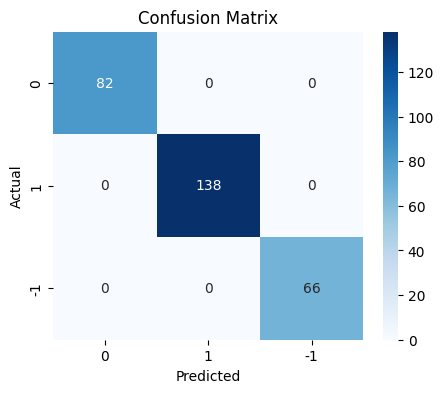

In [86]:
plot_confusion_matrix(rf_word2vec_base, df_Word2Vec_train, Y_train)

In [87]:
word2vec_base_train = model_performance_classification_sklearn(rf_word2vec_base, df_Word2Vec_train, Y_train)
print("Training performance:")
word2vec_base_train

Training performance:


,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


##### Checking model performance on Validation Set

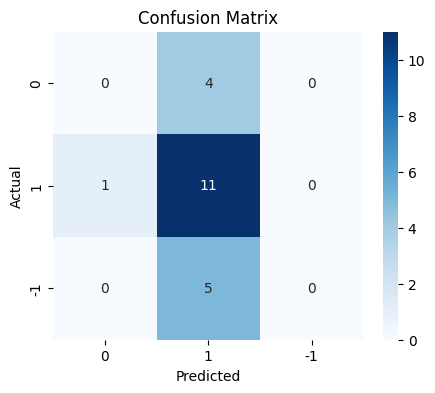

In [88]:
plot_confusion_matrix(rf_word2vec_base, df_Word2Vec_val, Y_val)

In [89]:
word2vec_base_val = model_performance_classification_sklearn(rf_word2vec_base, df_Word2Vec_val, Y_val)
print("Validation performance:")
word2vec_base_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.52381,0.52381,0.314286,0.392857


### **Using GloVe**

#### **RF Base Model**

In [90]:
# Building the model
rf_glovec_base = RandomForestClassifier(class_weight="balanced", random_state = 42)

# Fitting on train data
rf_glovec_base.fit(df_Glove_train, Y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

##### Checking model performance on Training Set

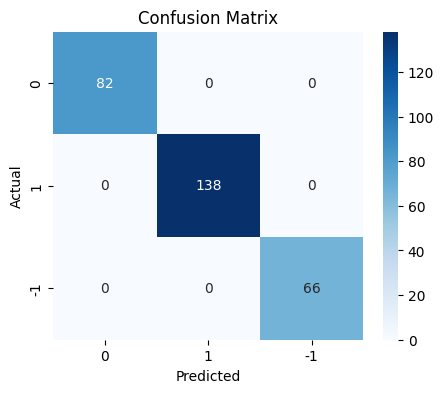

In [91]:
plot_confusion_matrix(rf_glovec_base, df_Glove_train, Y_train)

In [92]:
#Calculating different metrics on training data
glove_base_train = model_performance_classification_sklearn(rf_glovec_base, df_Glove_train, Y_train)
print("Training performance:")
glove_base_train

Training performance:


,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


##### Checking model performance on Validation Set

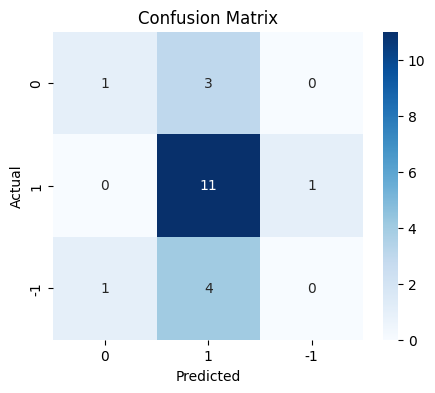

In [93]:
plot_confusion_matrix(rf_glovec_base, df_Glove_val, Y_val)

In [94]:
glove_base_val = model_performance_classification_sklearn(rf_glovec_base, df_Glove_val, Y_val)
print("Validation performance:")
glove_base_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.571429,0.571429,0.444444,0.48254


### **Using Sentence Transformers**

#### **RF Base Model**

In [95]:
# Building the model
rf_transformer = RandomForestClassifier(n_estimators = 100, max_depth = 7, random_state = 42)

# Fitting on train data
rf_transformer.fit(df_ST_train, Y_train)

RandomForestClassifier(max_depth=7, random_state=42)

##### Checking model performance on Training set

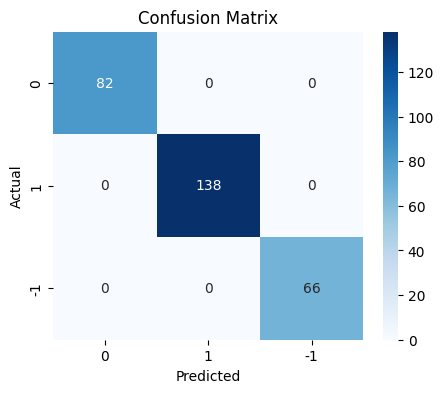

In [96]:
plot_confusion_matrix(rf_transformer, df_ST_train, Y_train)

In [97]:
st_base_train = model_performance_classification_sklearn(rf_transformer, df_ST_train, Y_train)
print("Training performance:")
glove_base_train

Training performance:


,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


##### Checking model performance on Validation set

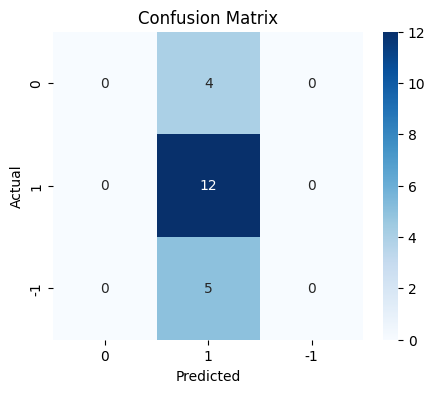

In [98]:
plot_confusion_matrix(rf_transformer, df_ST_val, Y_val)

In [99]:
st_base_val = model_performance_classification_sklearn(rf_transformer, df_ST_val, Y_val)
print("Validation performance:")
st_base_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.571429,0.571429,0.326531,0.415584


## **Tuned Models using Word Embeddings**

### **RF Model with Grid Search (Hyperparameter Tuning)**

In [100]:
# Choose the type of classifier.
word2vec_rf_tuned = RandomForestClassifier(class_weight= "balanced", random_state=1, bootstrap=True)

parameters = {
    'max_depth': list(np.arange(5,10,2)),
    'n_estimators': np.arange(50,110,25),
    'max_features': [0.3,0.4]
}

# Run the grid search
grid_obj = GridSearchCV(word2vec_rf_tuned, parameters, scoring='f1_weighted',cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(df_Word2Vec_train, Y_train)

# Set the clf to the best combination of parameters
word2vec_rf_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
word2vec_rf_tuned.fit(df_Word2Vec_train, Y_train)

RandomForestClassifier(class_weight='balanced', max_depth=5, max_features=0.4,
                       random_state=1)

#### Checking model performance on Training Set

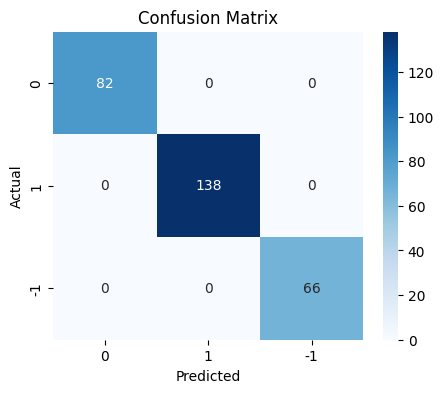

In [101]:
# Checking model performance on Training set
plot_confusion_matrix(word2vec_rf_tuned, df_Word2Vec_train, Y_train)

In [102]:
word2vec_tuned_train = model_performance_classification_sklearn(word2vec_rf_tuned, df_Word2Vec_train, Y_train)
print("Training performance:\n")
word2vec_tuned_train

Training performance:



,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


#### Checking model performance on Validation Set

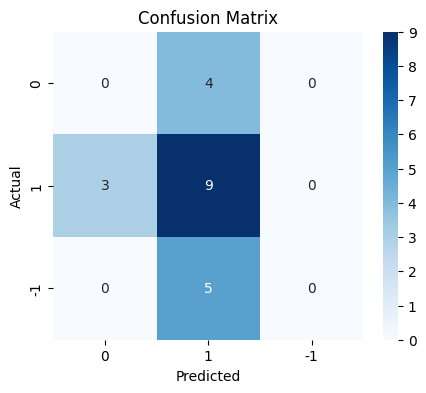

In [103]:
plot_confusion_matrix(word2vec_rf_tuned, df_Word2Vec_val, Y_val)

In [104]:
word2vec_tuned_val = model_performance_classification_sklearn(word2vec_rf_tuned, df_Word2Vec_val, Y_val)
print("Validation performance:\n")
word2vec_tuned_val

Validation performance:



,Accuracy,Recall,Precision,F1
0,0.428571,0.428571,0.285714,0.342857


### **RF Model with Grid Search (Hyperparameter Tuning)**

In [105]:
# Choose the type of classifier.
glove_rf_tuned = RandomForestClassifier(class_weight= "balanced", random_state=1, bootstrap=True)

parameters = {
    'max_depth': list(np.arange(5,10,2)),
    'n_estimators': np.arange(50,110,25),
    'max_features': [0.3,0.4]
}

# Run the grid search
# grid_obj = GridSearchCV(glove_rf_tuned, parameters, scoring='recall',cv=5,n_jobs=-1)
grid_obj = GridSearchCV(glove_rf_tuned, parameters, scoring='f1_weighted',cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(df_Glove_train, Y_train)

# Set the clf to the best combination of parameters
glove_rf_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
glove_rf_tuned.fit(df_Glove_train, Y_train)

RandomForestClassifier(class_weight='balanced', max_depth=9, max_features=0.4,
                       n_estimators=75, random_state=1)

##### Checking model performance on Training set

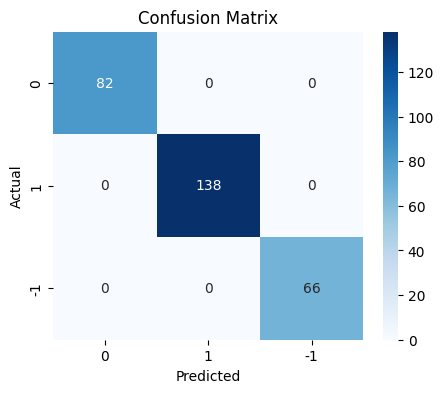

In [106]:
plot_confusion_matrix(glove_rf_tuned, df_Glove_train, Y_train)

In [107]:
glove_tuned_train = model_performance_classification_sklearn(glove_rf_tuned, df_Glove_train, Y_train)
print("Training performance:")
glove_tuned_train

Training performance:


,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


##### Checking model performance on Validation set

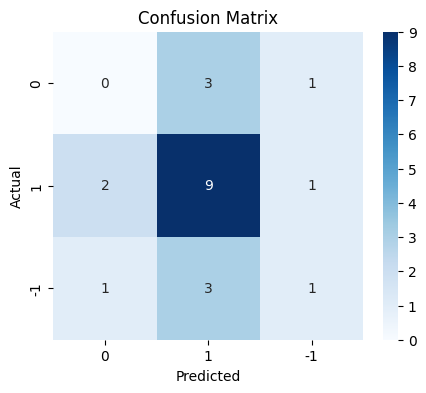

In [108]:
plot_confusion_matrix(glove_rf_tuned, df_Glove_val, Y_val)

In [109]:
glove_tuned_val = model_performance_classification_sklearn(glove_rf_tuned, df_Glove_val, Y_val)
print("Validation performance:")
glove_tuned_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.47619,0.47619,0.422222,0.440476


### **RF Model with Grid Search (Hyperparameter Tuning)**

In [110]:
# Choose the type of classifier.
rf_transformer_tuned = RandomForestClassifier(class_weight="balanced", random_state=1, bootstrap=True)

parameters = {
    'max_depth': list(np.arange(5,10,2)),
    'n_estimators': np.arange(50,110,25),
    'max_features': [0.3,0.4]
}

# Run the grid search
grid_obj = GridSearchCV(rf_transformer_tuned, parameters, scoring='f1_weighted',cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(df_ST_train, Y_train)

# Set the clf to the best combination of parameters
rf_transformer_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
rf_transformer_tuned.fit(df_ST_train, Y_train)

RandomForestClassifier(class_weight='balanced', max_depth=7, max_features=0.4,
                       n_estimators=75, random_state=1)

##### Checking model performance on Training set

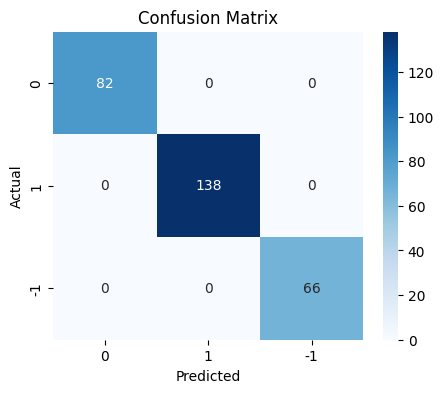

In [111]:
plot_confusion_matrix(rf_transformer_tuned, df_ST_train, Y_train)

In [112]:
st_tuned_train = model_performance_classification_sklearn(rf_transformer_tuned, df_ST_train, Y_train)
print("Training performance:")
st_tuned_train

Training performance:


,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


##### Checking model performance on Validation set

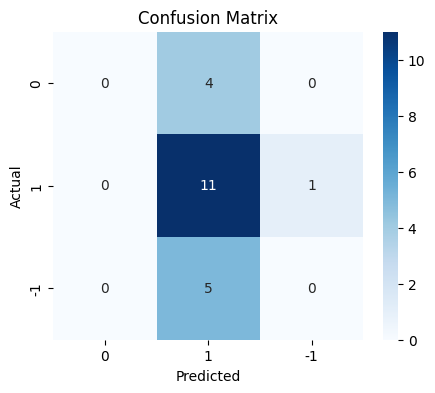

In [113]:
plot_confusion_matrix(rf_transformer_tuned, df_ST_val, Y_val)

In [114]:
st_tuned_val = model_performance_classification_sklearn(rf_transformer_tuned, df_ST_val, Y_val)
print("Validation performance:")
st_tuned_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.52381,0.52381,0.314286,0.392857


## **Model Comparison and Final Model Selection**

In [115]:
# Training performance comparison

models_train_comp_df = pd.concat(
    [word2vec_base_train.T,
     glove_base_train.T,
     st_base_train.T,

     word2vec_tuned_train.T,
     glove_tuned_train.T,
     st_tuned_train.T,

    ],axis=1
)

models_train_comp_df.columns = [
    "Base_Model (Word2Vec)",
    "Base_Model (GloVe)",
    "Base_Model (Sentence_Transformer)",
    "Tuned_Model (Word2Vec)",
    "Tuned_Model (GloVe)",
    "Tuned_Model (Sentence_Transformer)",
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Base_Model (Word2Vec),Base_Model (GloVe),Base_Model (Sentence_Transformer),Tuned_Model (Word2Vec),Tuned_Model (GloVe),Tuned_Model (Sentence_Transformer)
Accuracy,1.0,1.0,1.0,1.0,1.0,1.0
Recall,1.0,1.0,1.0,1.0,1.0,1.0
Precision,1.0,1.0,1.0,1.0,1.0,1.0
F1,1.0,1.0,1.0,1.0,1.0,1.0


In [116]:
# Validation performance comparison

models_train_comp_df = pd.concat(
    [word2vec_base_val.T,
     glove_base_val.T,
     st_base_val.T,

     word2vec_tuned_val.T,
     glove_tuned_val.T,
     st_tuned_val.T,

    ],axis=1
)

models_train_comp_df.columns = [
    "Base_Model (Word2Vec)",
    "Base_Model (GloVe)",
    "Base_Model (Sentence_Transformer)",
    "Tuned_Model (Word2Vec)",
    "Tuned_Model (GloVe)",
    "Tuned_Model (Sentence_Transformer)",
]

print("Validation performance comparison:")
models_train_comp_df

Validation performance comparison:


,Base_Model (Word2Vec),Base_Model (GloVe),Base_Model (Sentence_Transformer),Tuned_Model (Word2Vec),Tuned_Model (GloVe),Tuned_Model (Sentence_Transformer)
Accuracy,0.523810,0.571429,0.571429,0.428571,0.476190,0.523810
Recall,0.523810,0.571429,0.571429,0.428571,0.476190,0.523810
Precision,0.314286,0.444444,0.326531,0.285714,0.422222,0.314286
F1,0.392857,0.482540,0.415584,0.342857,0.440476,0.392857


## **Comment on model performance across different metrics**

### **Observations:**

- **Training Set Performance:**

    - All Models (Base and Tuned):
        - Achieved perfect scores across all metrics (Accuracy, Precision, Recall, F1 = 1.0).
        - This indicates the models fit the training data completely.
    - Observation:
        - Such perfect performance is unrealistic on real-world data and strongly suggests overfitting, since validation scores are much lower compared to training scores.

- **Validation Set Performance:**

    - Base Models:
        - GloVe Base Model achieved the best performance with F1-score = 0.4825 and Accuracy = 0.5714.
        - Sentence Transformer Base Model is the second-best with F1-score = 0.4155, better than Word2Vec.
        - Word2Vec Base Model performed the weakest across all metrics (F1-score = 0.3686).

    - Tuned Models:
        - Word2Vec improved slightly after tuning (F1 from 0.3686 → 0.3928), showing positive impact of hyperparameter tuning.
        - GloVe performance decreased after tuning (F1 from 0.4825 → 0.4404), indicating tuning was not effective.
        - Sentence Transformer performance also dropped after tuning (F1 from 0.4155 → 0.3928).

**- Overall Observation:**
    - Base models, especially GloVe, performed better than tuned models.
    - Hyperparameter tuning did not significantly improve results and in some cases reduced performance.

## **Choose the best model from the ones built with proper reasoning**

### **Observations:**

- **Based on the Training performance comparison:**

    - All models achieved perfect scores (Accuracy, Precision, Recall, F1 = 1.0) on the training set, indicating possible overfitting since validation performance is significantly lower.

- **Based on the validation performance comparison:**

    - Evaluation Metric Chosen: We prioritize F1-score (weighted) because the dataset is imbalanced (Neutral class dominates). F1-score balances Precision and Recall, making it more reliable than accuracy.

    - Performance Summary:
        - Base GloVe Model achieved the highest F1-score (0.4825) and good accuracy (0.5714).
        - Sentence Transformer Base Model is second (F1 = 0.4155), better than Word2Vec.
        - Tuned Models did not significantly outperform base models. GloVe and Sentence Transformer even decreased after tuning, suggesting possible overfitting or ineffective parameter ranges.

    - Precision and Recall: All models have low precision, meaning they predict extra false positives, but GloVe still maintains the best balance between recall and precision.


- **`Final Conclusion:`** The *`Base GloVe Model with Random Forest`* is selected as *`the best model`* because it achieves the highest F1-score on the validation set, provides a good balance between precision and recall, and tuning did not yield significant improvements.

## **Check the performance of the final model on the test set**

#### Checking model performance on Test set

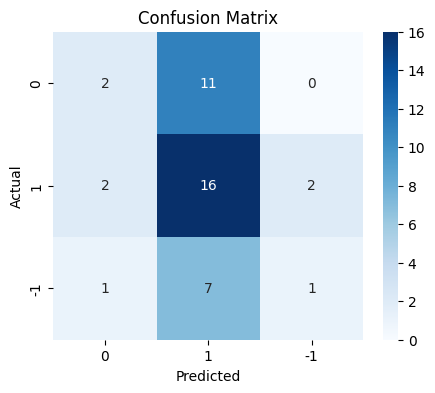

In [117]:
plot_confusion_matrix(rf_glovec_base, df_Glove_test, Y_test)

In [118]:
final_model_test = model_performance_classification_sklearn(rf_glovec_base, df_Glove_test, Y_test)
print("Test performance for the final model:")
final_model_test

Test performance for the final model:


,Accuracy,Recall,Precision,F1
0,0.452381,0.452381,0.419328,0.386684


### Observations:

- Accuracy (45.2%) and F1-score (0.3867) are low, indicating poor generalization.

- Performance is similar to validation results, confirming overfitting.

- Neutral class dominates predictions due to class imbalance.

- Model needs improvements like better embeddings, class balancing, or advanced algorithms.

# **Content Summarization**

## **Weekly News Summarization**

**Important Note**: It is recommended to run this section of the project independently from the previous sections in order to avoid runtime crashes due to RAM overload.

#### Installing and Importing the necessary libraries

In [ ]:
# Installation for GPU llama-cpp-python
# uncomment and run the following code in case GPU is being used
!CMAKE_ARGS="-DLLAMA_CUBLAS=on" FORCE_CMAKE=1 pip install llama-cpp-python==0.2.45 --force-reinstall --no-cache-dir -q

# Installation for CPU llama-cpp-python
# uncomment and run the following code in case GPU is not being used
# !CMAKE_ARGS="-DLLAMA_CUBLAS=off" FORCE_CMAKE=1 pip install llama-cpp-python==0.2.45 --force-reinstall --no-cache-dir -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 74.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 173.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 214.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 kB 226.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 107.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 168.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.2 which is incompatible.
opencv-python-headless 4.12.0.88 

In [ ]:
# Function to download the model from the Hugging Face model hub
from huggingface_hub import hf_hub_download

# Importing the Llama class from the llama_cpp module
from llama_cpp import Llama

# Importing the library for data manipulation
import pandas as pd

from tqdm import tqdm # For progress bar related functionalities
tqdm.pandas()

#### Loading the data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# loading data into a pandas dataframe
stock_news = pd.read_csv("/content/drive/MyDrive/NLP/stock_news.csv")

In [ ]:
data = stock_news.copy()
data.head()

#### Loading the model

In [ ]:
# Load Mistral model
model_name_or_path = "TheBloke/Mistral-7B-Instruct-v0.2-GGUF"
model_basename = "mistral-7b-instruct-v0.2.Q6_K.gguf"

In [ ]:
model_path = hf_hub_download(repo_id=model_name_or_path, filename=model_basename)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


mistral-7b-instruct-v0.2.Q6_K.gguf:   0%|          | 0.00/5.94G [00:00<?, ?B/s]

In [ ]:
llm = Llama(
    model_path=model_path, # Path to the model
    n_gpu_layers=100, #Number of layers transferred to GPU
    n_ctx=4500, #Context window
)

llama_model_loader: loaded meta data with 24 key-value pairs and 291 tensors from /root/.cache/huggingface/hub/models--TheBloke--Mistral-7B-Instruct-v0.2-GGUF/snapshots/3a6fbf4a41a1d52e415a4958cde6856d34b2db93/mistral-7b-instruct-v0.2.Q6_K.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = llama
llama_model_loader: - kv   1:                               general.name str              = mistralai_mistral-7b-instruct-v0.2
llama_model_loader: - kv   2:                       llama.context_length u32              = 32768
llama_model_loader: - kv   3:                     llama.embedding_length u32              = 4096
llama_model_loader: - kv   4:                          llama.block_count u32              = 32
llama_model_loader: - kv   5:                  llama.feed_forward_length u32              = 14336
llama_model_loade

#### Aggregating the data weekly

In [ ]:
data["Date"] = pd.to_datetime(data['Date'])  # Convert the 'Date' column to datetime format.

In [ ]:
# Group the data by week using the 'Date' column.
weekly_grouped = data.groupby(pd.Grouper(key='Date', freq='W'))

In [ ]:
weekly_grouped = weekly_grouped.agg(
    {
        'News': lambda x: ' || '.join(x)  # Join the news values with ' || ' separator.
    }
).reset_index()

print(weekly_grouped.shape)

(18, 2)


In [ ]:
weekly_grouped

,Date,News
0,2019-01-06,The tech sector experienced a significant dec...
1,2019-01-13,Sprint and Samsung plan to release 5G smartph...
2,2019-01-20,The U.S. stock market declined on Monday as c...
3,2019-01-27,"The Swiss National Bank (SNB) governor, Andre..."
4,2019-02-03,Caterpillar Inc reported lower-than-expected ...
5,2019-02-10,"The Dow Jones Industrial Average, S&P 500, an..."
6,2019-02-17,"This week, the European Union's second highes..."
7,2019-02-24,This news article discusses progress towards ...
8,2019-03-03,The Dow Jones Industrial Average and other ma...
9,2019-03-10,"Spotify, the world's largest paid music strea..."


In [ ]:
# creating a copy of the data
data_1 = weekly_grouped.copy()

#### Summarization

**Note**:

- The model is expected to summarize the news from the week by identifying the top three positive and negative events that are most likely to impact the price of the stock.

- As an output, the model is expected to return a JSON containing two keys, one for Positive Events and one for Negative Events.

For the project, we need to define the prompt to be fed to the LLM to help it understand the task to perform. The following should be the components of the prompt:

1. **Role**: Specifies the role the LLM will be taking up to perform the specified task, along with any specific details regarding the role

  - **Example**: `You are an expert data analyst specializing in news content analysis.`

2. **Task**: Specifies the task to be performed and outlines what needs to be accomplished, clearly defining the objective

  - **Example**: `Analyze the provided news headline and return the main topics contained within it.`

3. **Instructions**: Provides detailed guidelines on how to perform the task, which includes steps, rules, and criteria to ensure the task is executed correctly

  - **Example**:

```
Instructions:
1. Read the news headline carefully.
2. Identify the main subjects or entities mentioned in the headline.
3. Determine the key events or actions described in the headline.
4. Extract relevant keywords that represent the topics.
5. List the topics in a concise manner.
```

4. **Output Format**: Specifies the format in which the final response should be structured, ensuring consistency and clarity in the generated output

  - **Example**: `Return the output in JSON format with keys as the topic number and values as the actual topic.`

**Full Prompt Example**:

```
You are an expert data analyst specializing in news content analysis.

Task: Analyze the provided news headline and return the main topics contained within it.

Instructions:
1. Read the news headline carefully.
2. Identify the main subjects or entities mentioned in the headline.
3. Determine the key events or actions described in the headline.
4. Extract relevant keywords that represent the topics.
5. List the topics in a concise manner.

Return the output in JSON format with keys as the topic number and values as the actual topic.
```

**Sample Output**:

`{"1": "Politics", "2": "Economy", "3": "Health" }`

##### Utility Functions

In [ ]:
# defining a function to parse the JSON output from the model
def extract_json_data(json_str):
    import json
    try:
        # Find the indices of the opening and closing curly braces
        json_start = json_str.find('{')
        json_end = json_str.rfind('}')

        if json_start != -1 and json_end != -1:
            extracted_category = json_str[json_start:json_end + 1]  # Extract the JSON object
            data_dict = json.loads(extracted_category)
            return data_dict
        else:
            print(f"Warning: JSON object not found in response: {json_str}")
            return {}
    except json.JSONDecodeError as e:
        print(f"Error parsing JSON: {e}")
        return {}

##### Defining the response function

In [ ]:
#Defining the response function
def response_mistral_1(prompt, news):
    model_output = llm(
      f"""
      [INST]
      {prompt}
      News Articles: {news}
      [/INST]
      """,
      max_tokens= 256 #512 #1024, #Complete the code to set the maximum number of tokens the model should generate for this task.
      temperature= 0, #Complete the code to set the value for temperature.
      top_p= 0.95, #Complete the code to set the value for top_p
      top_k= 50, #Complete the code to set the value for top_k
      echo=False,
    )

    final_output = model_output["choices"][0]["text"]

    return final_output

##### Checking the model output on a sample

**Note**: Use this section to test out the prompt with one instance before using it for the entire weekly data.

In [ ]:
news = data_1.loc[8, 'News']

In [ ]:
print(len(news.split(' ')))
news

422


" The Dow Jones Industrial Average and other major indexes posted gains on Monday, with the Dow rising 60 points, after President Trump announced progress in trade talks with China and delayed tariff hikes. Trade-sensitive stocks like Boeing and Caterpillar performed well, but some tariffs are expected to remain as an enforcement mechanism ||  AAC Technologies Holdings, an Apple supplier based in Hong Kong, reported a significant decrease in expected net profit for Q1 2019 due to reduced orders from customers. The company forecasted a profit decline of 65-75% compared to the same period last year and narrowing gross profit margins. AAC ||  Huawei, the world's third-largest smartphone vendor, showcased its new folding phone, the Mate X, on February 24. The device is designed for next-generation 5G networks and promises super-fast internet speeds. Despite US efforts to exclude the Chinese company from 5G networks ||  Sony, aiming to differentiate itself in the smartphone market, unveiled

In [ ]:
# prompt for this task
prompt = """
    You are an expert data analyst specializing in news content analysis.

Task: Analyze the provided news headline and return the main topics contained within it.

Instructions:
1. Read the news headline carefully.
2. Identify the main subjects or entities mentioned in the headline.
3. Determine the key events or actions described in the headline.
4. Extract relevant keywords that represent the topics.
5. List the topics in a concise manner.

Return the output in JSON format with keys as the topic number and values as the actual topic.
"""

In [ ]:
summary = response_mistral_1(prompt, news)
print(summary)


llama_print_timings:        load time =     712.76 ms
llama_print_timings:      sample time =     115.23 ms /   213 runs   (    0.54 ms per token,  1848.44 tokens per second)
llama_print_timings: prompt eval time =    1075.80 ms /   799 tokens (    1.35 ms per token,   742.70 tokens per second)
llama_print_timings:        eval time =    6839.53 ms /   212 runs   (   32.26 ms per token,    31.00 tokens per second)
llama_print_timings:       total time =    8704.76 ms /  1011 tokens


 [
        1: "Trade Talks between US and China",
        2: "President Trump's Announcement on Tariff Hikes",
        3: "Performance of Trade-sensitive Stocks (Boeing, Caterpillar)",
        4: "AAC Technologies Holdings' Decrease in Net Profit",
        5: "Huawei's New Folding Phone (Mate X)",
        6: "Sony's New Flagship Xperia 1",
        7: "Warren Buffett's Unexpected Exit from Oracle Corp",
        8: "Huawei's Defense of Position Amid Trade Tensions",
        9: "AAC Technologies Holdings' First-quarter Profit Decline",
        10: "Apple's Layoffs from Project Titan",
        11: "Spotify's Entry into Indian Market"
      ]


##### Checking the model output on the weekly data

In [ ]:
data_1['Key Events'] = data_1['News'].progress_apply(lambda x: response_mistral_1(prompt,x))

  0%|          | 0/18 [00:00<?, ?it/s]Llama.generate: prefix-match hit

llama_print_timings:        load time =     712.76 ms
llama_print_timings:      sample time =     615.33 ms /   512 runs   (    1.20 ms per token,   832.08 tokens per second)
llama_print_timings: prompt eval time =    4462.70 ms /  3744 tokens (    1.19 ms per token,   838.95 tokens per second)
llama_print_timings:        eval time =   21381.53 ms /   511 runs   (   41.84 ms per token,    23.90 tokens per second)
llama_print_timings:       total time =   31762.12 ms /  4255 tokens
 11%|█         | 2/18 [00:31<04:14, 15.89s/it]Llama.generate: prefix-match hit

llama_print_timings:        load time =     712.76 ms
llama_print_timings:      sample time =     232.48 ms /   434 runs   (    0.54 ms per token,  1866.80 tokens per second)
llama_print_timings: prompt eval time =    2567.72 ms /  2234 tokens (    1.15 ms per token,   870.03 tokens per second)
llama_print_timings:        eval time =   16079.99 ms /   433 runs

In [ ]:
data_1['Key Events'].head()

,Key Events
0,"[\n {\n ""topic_1"": ""Apple's Q..."
1,"{\n ""1"": ""5G smartphones release in n..."
2,"{\n ""1"": ""U.S. stock market decline"",..."
3,"{\n ""1"": ""Swiss National Bank (SNB) a..."
4,"{\n ""1"": ""Caterpillar Inc's lower-th..."


##### Formatting the model output

In [ ]:
data_1['model_response_parsed'] = data_1['Key Events'].apply(extract_json_data)
data_1.head()

Error parsing JSON: Extra data: line 4 column 10 (char 272)
         "1": "U.S. stock market decline",
         "2": "Global economic slowdown concerns",
         "3": "Chinese exports and imports drop",
         "4": "Tech stocks losses",
         "5": "Philadelphia SE Semiconductor Index decline",
         "6": "European stock market rally halt",
         "7": "Luxury retailers stock decline",
         "8": "Chinese auto market contraction",
         "9": "US-China trade war impact on Chinese auto market",
         "10": "Dialog Semiconductor revenue report",
         "11": "Crude oil price drop",
         "12": "Chinese economy weakening as a factor in crude oil price drop",
         "13": "Dow Jones Industrial Average and S&P 500 decline",
         "14": "Apple potential self-driving vehicle program cutbacks",
         "15": "Qualcomm patent lawsuit dismissal",
         "16": "Apple iPhone sales impact on suppliers",
         "17": "U.S. stocks rise with technology and internet com

,Date,News,Key Events,model_response_parsed
0,2019-01-06,The tech sector experienced a significant dec...,"[\n {\n ""topic_1"": ""Apple's Q...",{}
1,2019-01-13,Sprint and Samsung plan to release 5G smartph...,"{\n ""1"": ""5G smartphones release in n...",{'1': '5G smartphones release in nine U.S. cit...
2,2019-01-20,The U.S. stock market declined on Monday as c...,"{\n ""1"": ""U.S. stock market decline"",...",{}
3,2019-01-27,"The Swiss National Bank (SNB) governor, Andre...","{\n ""1"": ""Swiss National Bank (SNB) a...",{'1': 'Swiss National Bank (SNB) and negative ...
4,2019-02-03,Caterpillar Inc reported lower-than-expected ...,"{\n ""1"": ""Caterpillar Inc's lower-th...",{}


In [ ]:
model_response_parsed = pd.json_normalize(data_1['model_response_parsed'])
model_response_parsed.head()

,1,2,3,4,5,6,7,8,9,10,...,topic_11,topic_12,topic_13,22,23,topic_14,topic_15,topic_16,topic_17,topic_18
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5G smartphones release in nine U.S. cities,AMS developing new 3D facial recognition featu...,Vivendi's Universal Music Group valuation incr...,Amazon stock predicted to surge by over 20%,AMS partnering with Chinese software maker Fac...,Geely forecasting flat sales for 2019,China making efforts to address U.S. concerns ...,Progress in U.S.-China trade talks,Qualcomm expanding lineup of car computing chips,Mercedes Benz top selling premium automotive b...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Swiss National Bank (SNB) and negative interes...,"Stock market losses (Dow, S&P 500, Nasdaq)",IBM's better-than-expected earnings and revenue,Huawei's new Honor View20 smartphone launch,Foxconn recruitment drive and potential layoffs,Amazon's direct fulfillment and delivery netwo...,Tesla's potential battery supplier negotiation...,TomTom's sale of fleet management business to ...,Japan Display's potential funding from Taiwan'...,White House-China trade negotiations and intel...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
final_output = pd.concat([data_1.reset_index(drop=True),model_response_parsed],axis=1)
final_output.drop(['Key Events','model_response_parsed'], axis=1, inplace=True)
# Get the existing column count
num_columns = len(final_output.columns)
# Create a list of new column names with the correct length
new_column_names = ['Week End Date', 'News'] + [f'Column_{i}' for i in range(2, num_columns)]
# Assign the new column names
final_output.columns = new_column_names

final_output.head()

,Week End Date,News,Column_2,Column_3,Column_4,Column_5,Column_6,Column_7,Column_8,Column_9,...,Column_33,Column_34,Column_35,Column_36,Column_37,Column_38,Column_39,Column_40,Column_41,Column_42
0,2019-01-06,The tech sector experienced a significant dec...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-01-13,Sprint and Samsung plan to release 5G smartph...,5G smartphones release in nine U.S. cities,AMS developing new 3D facial recognition featu...,Vivendi's Universal Music Group valuation incr...,Amazon stock predicted to surge by over 20%,AMS partnering with Chinese software maker Fac...,Geely forecasting flat sales for 2019,China making efforts to address U.S. concerns ...,Progress in U.S.-China trade talks,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-01-20,The U.S. stock market declined on Monday as c...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-01-27,"The Swiss National Bank (SNB) governor, Andre...",Swiss National Bank (SNB) and negative interes...,"Stock market losses (Dow, S&P 500, Nasdaq)",IBM's better-than-expected earnings and revenue,Huawei's new Honor View20 smartphone launch,Foxconn recruitment drive and potential layoffs,Amazon's direct fulfillment and delivery netwo...,Tesla's potential battery supplier negotiation...,TomTom's sale of fleet management business to ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-02-03,Caterpillar Inc reported lower-than-expected ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **Conclusions and Recommendations**

## **Actionable Insights**
GloVe embeddings performed best among the tested techniques (F1 = 0.4825 on validation), but overall scores were moderate, indicating limited predictive power of current features.

Hyperparameter tuning did not improve performance significantly and, in some cases, decreased it, suggesting the need for a better feature set or different models.

Training performance was perfect (F1 = 1.0) while validation and test scores were low, confirming overfitting.

Class imbalance is evident (Neutral ~48%, Negative ~28%, Positive ~23%), impacting model performance, especially precision.

Sentiment polarity shows some correlation with stock price movements, but the relationship is weak, meaning news sentiment alone is insufficient for accurate prediction.

## **Recommendations:**

- Feature Engineering Enhancements:

Incorporate technical indicators (e.g., moving averages, volatility) along with news sentiment.

Include news source credibility, keyword frequency, and topic modeling as additional features.

Model Improvements:

Use transformer-based embeddings (e.g., BERT, FinBERT) instead of static embeddings for better context capture.

Try ensemble models (XGBoost, LightGBM) or deep learning models (LSTM, Transformer models) for sequential data.

Handle Class Imbalance:

Apply SMOTE, oversampling, undersampling, or class-weight adjustments to balance labels.

Regularization and Validation:

Use time-series cross-validation instead of random split for better temporal consistency.

Business Impact:

Current model can be used for basic trend indication but not for critical trading decisions.

Before deployment, ensure improvements and backtest the strategy on historical data.

<font size=6 color='blue'>Power Ahead</font>
___